<div style="font-family: Arial;">
<img src="https://udemedellin.edu.co/wp-content/uploads/2022/10/logo_udemedellin2.png" width="30%">
<h3 style="text-align: center;">
<b>ESPECIALIZACIÓN EN CIENCIA DE DATOS E INTELIGENCIA ARTIFICIAL</b>
</h3>
<h3 style="text-align: center; color:  #C2262B;">
<strong>PROYECTO 1</strong>
</h3>
<h3>
<b>Tema:</b> Proyección de ventas
</h3>
<hr style="width:100%; border:1px solid white;">
<h6 style="text-align: right; margin-bottom: 5px">
<b>INTEGRANTES:</b> Bueno Osorno Dubian Andres
- Ceballos Bedoya Catherine - Rivera Guzman Yesenia - Salazar Seguro Maria Jimena
 <br><b>FECHA:</b> 15-05-2026<br>
</h6>
</div>

---

# Proyección de ventas a 6 meses

Este proyecto desarrolla un modelo de proyección de ventas a seis meses para una compañía colombiana con cinco sucursales (Medellín, Bogotá, Cali, Barranquilla y Cartagena) y operación B2B en múltiples sectores. El dataset disponible contiene aproximadamente 890 mil líneas de factura correspondientes a dos años de operación.

El producto final se entrega al área comercial como insumo para toma de decisiones: planeación de cuotas, asignación de equipos por sucursal, priorización de productos y monitoreo de cartera.

**Estructura del trabajo:**

1. Carga del archivo y validación inicial.
2. Limpieza y conversión de tipos (formato europeo, fechas en string, normalización de prefijos).
3. Detección de valores atípicos y nulos.
4. Análisis exploratorio (EDA) descriptivo y visual, con énfasis en patrones cruzados entre sucursal, sector, producto y estado de pago.
5. Aplicación de la lógica de negocio sobre `sequence_prefix`: las facturas reales suman, las devoluciones (`D`) y notas crédito (`N`, `N5`) restan, las notas débito (`ND`) suman. El resultado es la métrica **venta neta**, que es lo que finalmente se proyecta.
6. Construcción de un panel mensual a nivel (sucursal × sector) y (sucursal × producto).
7. Feature engineering temporal: lags, medias móviles, calendario y variables de actividad.
8. Pipeline de preprocesamiento con `sklearn.Pipeline` para garantizar replicabilidad.
9. Entrenamiento de un Random Forest y optimización de hiperparámetros vía `RandomizedSearchCV` con validación cruzada temporal.
10. Proyección recursiva a seis meses con el modelo optimizado.
11. Análisis de importancia de variables vía Permutation Importance.
12. Exportación de los resultados en formato CSV listo para Power BI.

**Consideración previa:** las series mensuales por (sucursal × sector) son cortas (28 meses) y heterogéneas, lo que pone un techo natural a la precisión alcanzable. El objetivo no es minimizar el error a toda costa, sino entregar una proyección defendible y trazable, con métricas comparables contra baselines simples para evaluar honestamente la contribución del modelo.

## 1. Setup

In [1]:
# Librerías
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Configuración visual
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

pd.set_option("display.max_columns", None)

# Path al CSV — ajustar si está en otra ubicación
RUTA_CSV = r"C:\Users\andre\Documents\Proyectos\Ciencia-datos-DABO\Proyecto\Ventas.csv"

# Mapa de sucursales (de la documentación del dataset)
BODEGAS = {1: 'Medellín', 2: 'Bogotá', 3: 'Cali', 4: 'Barranquilla', 5: 'Cartagena'}

# Convención de signos por tipo de documento
SIGNO_PREFIX = {
    'FBAQ': 1, 'FBOG': 1, 'FCAL': 1, 'FCAR': 1, 'FMED': 1,  # facturas de venta
    'ND':  1,                                                  # notas débito (suman)
    'D':  -1,                                                  # devoluciones (restan)
    'N':  -1, 'N5': -1                                         # notas crédito (restan)
}

print('Setup listo.')

Setup listo.


## 2. Carga del archivo

El archivo viene en separador `;`, codificación `latin-1` (UTF-8 falla por caracteres con tilde mal codificados desde el ERP) y con números en formato europeo: punto como separador de miles y coma como decimal. Las fechas se almacenan como string en formato `dd/mm/yyyy`.

La carga inicial trae todas las columnas del archivo. En una etapa posterior se restringe a las que el análisis realmente usa, pero conviene revisar primero la estructura completa para entender el contenido.

In [2]:
try:
    
    df = pd.read_csv(RUTA_CSV, sep=';', encoding='latin-1')
except FileNotFoundError:
    raise FileNotFoundError(
        f"No encontré '{RUTA_CSV}'. Verifica la ruta o ajusta la variable RUTA_CSV."
    )

print(f'Filas cargadas: {len(df):,}')
print(f'Columnas: {df.shape[1]}')
df.head(3)

Filas cargadas: 889,841
Columnas: 31


,sequence_prefix,bodega,fe_es_compania,credit_limit,fecha_creacion,tipo_ext,bodega_vend,cod_vend_ext,cod_int,tipo_int,factura,id_cliente,fecha,fecha_vencimiento,amount_untaxed_signed,amount_tax_signed,amount_total_signed,payment_state,asociacion_cliente,referencia,dpto,subgrupo,venta,tipo_linea,id_sector,sector,id_subsector,subsector,Fecha de creacion,fe_es_autorrenta,fe_es_gran_contribuyente
0,FMED,1,2,0,0,0,1,1,01,0,FMED667491,193.53,02/01/2025,1/01/25,"39.567,00","7.517,73","47.084,73",paid,01,152040040,15,1501,"39.567,00",otras_lineas,42,Empleados,0,0,11/03/2022,FALSO,FALSO
1,D,1,2,0,0,0,1,1,01,0,D132143,193.53,02/01/2025,2/01/25,"-39.567,00","-7.517,73","-47.084,73",paid,01,152040040,15,1501,"-39.567,00",otras_lineas,42,Empleados,0,0,11/03/2022,FALSO,FALSO
2,FMED,3,2,"50.000.000,00",0,externo,3,331,I34,interno,FMED667492,73.04,02/01/2025,1/02/25,"720.000,00","136.800,00","856.800,00",in_payment,331,790589737,79,7902,"720.000,00",otras_lineas,24,Comercio,0,0,03/12/2007,VERDADERO,FALSO


In [3]:
cols_uso = ['sequence_prefix','bodega','factura','fecha','venta',
                'amount_untaxed_signed','amount_total_signed',
                'payment_state','dpto','sector','subsector']

In [4]:
# Vistazo a tipos y nulos
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 889841 entries, 0 to 889840
Data columns (total 31 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   sequence_prefix           889841 non-null  str    
 1   bodega                    889841 non-null  int64  
 2   fe_es_compania            889841 non-null  int64  
 3   credit_limit              889841 non-null  str    
 4   fecha_creacion            889841 non-null  str    
 5   tipo_ext                  889841 non-null  str    
 6   bodega_vend               889841 non-null  int64  
 7   cod_vend_ext              889841 non-null  int64  
 8   cod_int                   889841 non-null  str    
 9   tipo_int                  889841 non-null  str    
 10  factura                   889841 non-null  str    
 11  id_cliente                889841 non-null  float64
 12  fecha                     889841 non-null  str    
 13  fecha_vencimiento         889841 non-null  str    
 14 

La mayoría de columnas entró tipada como `object`. El comportamiento es esperable: los números traen formato europeo (no parseable por defecto) y las fechas vienen como string. Los nulos están limpios en las columnas críticas para el análisis, así que el reto principal de esta sección es la conversión de tipos, no la imputación.

## 3. Limpieza y conversión de tipos

Operaciones realizadas en esta etapa:

- **`fecha`**: parseo a `datetime` con formato `dd/mm/yyyy`. Se replica para `fecha_vencimiento` y `Fecha de creacion`.
- **Columnas monetarias** (`venta`, `amount_untaxed_signed`, `amount_total_signed`): conversión vectorizada del formato europeo a `float64`. Se eliminan los puntos de miles y se reemplaza la coma decimal por punto antes del cast.
- **`sequence_prefix`**: se aplica `strip()` porque uno de los prefijos (`'N5 '`) viene con espacio extra desde la fuente, lo que rompería el mapeo posterior de signos.
- **`bodega`**: existe un único registro con `bodega=0`, que corresponde a una factura `FCAL` (Cali). Se imputa manualmente a `bodega=3`.
- **Validación del mapeo de signos**: se verifica que todos los prefijos del dataset estén contemplados en el diccionario `SIGNO_PREFIX`. Si apareciera un prefijo no mapeado, el `assert` aborta y obliga a revisar el negocio antes de continuar.

Todas las transformaciones se hacen vectorizadas. Con 900k filas, cualquier `apply` o `for` introduce penalizaciones de segundos que no son necesarias.

In [5]:
# 1. Strip al prefijo (caso 'N5 ' con espacio)
df['sequence_prefix'] = df['sequence_prefix'].astype(str).str.strip()

# 2. Fechas fecha_vencimiento y fecha de creación (formato europeo -> datetime) 
df['fecha'] = pd.to_datetime(df['fecha'], format='%d/%m/%Y', errors='coerce')
print(f"Fechas inválidas en fecha tras parsing: {df['fecha'].isna().sum()}")

df['Fecha de creacion'] = pd.to_datetime(df['fecha'], format='%d/%m/%Y', errors='coerce')
print(f"Fechas inválidas en Fecha de creacion tras parsing: {df['Fecha de creacion'].isna().sum()}")

df['fecha_vencimiento'] = pd.to_datetime(df['fecha'], format='%d/%m/%Y', errors='coerce')
print(f"Fechas inválidas en fecha_vencimiento tras parsing: {df['fecha_vencimiento'].isna().sum()}")


# 3. Conversión numérica vectorizada (formato europeo -> float)
def to_float_eur(s: pd.Series) -> pd.Series:
    return (s.astype(str)
             .str.replace('.', '', regex=False)
             .str.replace(',', '.', regex=False)
             .astype('float64'))

for c in ['venta', 'amount_untaxed_signed', 'amount_total_signed']:
    df[c] = to_float_eur(df[c])

# 4. Corrección puntual del bodega=0
n_fix = (df['bodega'] == 0).sum()
df.loc[df['bodega'] == 0, 'bodega'] = 3   # FCAL = Cali
print(f'Filas con bodega=0 corregidas: {n_fix}')

# 5. Validar mapping de signos antes de usarlo
prefijos = df['sequence_prefix'].unique()
faltantes = [p for p in prefijos if p not in SIGNO_PREFIX]
assert not faltantes, f'Prefijos sin mapeo: {faltantes}'
print(f'Prefijos encontrados ({len(prefijos)}): {sorted(prefijos)}')

Fechas inválidas en fecha tras parsing: 0
Fechas inválidas en Fecha de creacion tras parsing: 0
Fechas inválidas en fecha_vencimiento tras parsing: 0
Filas con bodega=0 corregidas: 1
Prefijos encontrados (9): ['D', 'FBAQ', 'FBOG', 'FCAL', 'FCAR', 'FMED', 'N', 'N5', 'ND']


In [6]:
# Resumen post-limpieza
df.describe(include='all').T.head(15)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
sequence_prefix,889841,9,FBOG,280645,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bodega,"889,841.00",NaN,NaN,NaN,2.40,1.00,1.00,2.00,3.00,5.00,1.32
fe_es_compania,"889,841.00",NaN,NaN,NaN,1.23,1.00,1.00,1.00,1.00,2.00,0.42
credit_limit,889841,230,0,107959,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_creacion,889841,3192,0,342160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_ext,889841,5,externo,592039,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bodega_vend,"889,841.00",NaN,NaN,NaN,2.40,0.00,1.00,2.00,3.00,5.00,1.32
cod_vend_ext,"889,841.00",NaN,NaN,NaN,240.60,0.00,56.00,230.00,327.00,599.00,161.95
cod_int,889841,106,I37,44824,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_int,889841,7,interno,577102,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Detección de nulos y atípicos

Las columnas relevantes para el modelo no presentan valores faltantes después de la conversión, lo cual simplifica el flujo. Lo que sí amerita inspección es la coherencia interna del dataset:

- **Signo por tipo de documento**: cada `sequence_prefix` debería respetar la convención del negocio (positivo o negativo según corresponda).
- **Valores extremos**: tickets de facturación inusualmente grandes que podrían sesgar agregaciones.
- **Rango temporal**: confirmar que el dataset cubre el período declarado (24 meses) sin huecos.

In [7]:
# Nulos por columna
nulos = df.isna().sum()
print('Nulos por columna:')
print(nulos[nulos > 0] if nulos.any() else '  (no hay nulos)')

# Rango temporal
print(f"\nRango de fechas: {df['fecha'].min().date()}  -->  {df['fecha'].max().date()}")
print(f"Meses cubiertos: {df['fecha'].dt.to_period('M').nunique()}")

Nulos por columna:
  (no hay nulos)

Rango de fechas: 2024-01-02  -->  2026-04-30
Meses cubiertos: 28


In [8]:
# Distribución de venta por tipo de documento — para sanity-check de signos
resumen_signo = (df.groupby('sequence_prefix')['venta']
                   .agg(['count','min','median','max'])
                   .round(0)
                   .sort_values('count', ascending=False))
print('Estadísticos de `venta` por tipo de documento:')
resumen_signo

Estadísticos de `venta` por tipo de documento:


,count,min,median,max
sequence_prefix,,,,
FBOG,280645,1.00,"223,776.00","160,954,733.00"
FMED,260016,"-933,000.00","179,088.00","432,000,000.00"
FCAL,139946,1.00,"158,300.00","138,063,900.00"
FCAR,102976,272.00,"172,500.00","2,390,787,000.00"
FBAQ,79428,177.00,"202,800.00","253,676,500.00"
D,26174,"-432,000,000.00","-201,960.00",-1.00
N,419,"-66,200,052.00","-54,720.00",-99.00
ND,210,"-19,000,800.00","201,950.00","56,610,494.00"
N5,27,"-21,219,932.00","-121,500.00",-664.00


**Hallazgos sobre los signos por tipo de documento:**

- Las facturas reales (`FBOG`, `FMED`, `FCAL`, `FCAR`, `FBAQ`) registran valores positivos como debe ser.
- Las devoluciones (`D`) y notas crédito (`N`, `N5`) llegan con signo negativo desde el origen, lo cual es coherente con su rol contable (restan del ingreso).
- Las notas débito (`ND`) son mayoritariamente positivas (209 de 210 registros), respetando su función de incrementar el ingreso.
- Aparece un detalle: `FMED` registra un mínimo negativo (-933.000), lo que sugiere que algunos ajustes contables se cargaron como factura sin haberse reclasificado a `D`. Este ruido del ERP existe en cualquier sistema transaccional.

**Decisión metodológica**: para que el cálculo del ingreso neto no dependa de cómo cada documento haya sido cargado en el ERP, se aplica una regla uniforme `venta_neta = signo_del_prefijo × |venta|`. Así, el resultado depende exclusivamente de la convención de negocio definida en `SIGNO_PREFIX` y no de inconsistencias puntuales en la fuente. Esta es la forma correcta de obtener el valor neto, sumando ingresos reales y restando devoluciones y notas crédito**.

In [9]:
# Outliers: ventas muy grandes en valor absoluto
# Uso el percentil 99.9 como umbral de revisión, no para eliminar
top = df['venta'].abs().quantile(0.999)
n_extremos = (df['venta'].abs() > top).sum()
print(f'Líneas por encima del p99.9 ({top:,.0f}): {n_extremos:,}')
print('Ejemplos (top 5 por valor absoluto):')
df.assign(venta_abs=df['venta'].abs()).nlargest(5, 'venta_abs')[
    ['fecha','sequence_prefix','bodega','sector','venta','factura']
]

Líneas por encima del p99.9 (34,947,360): 890
Ejemplos (top 5 por valor absoluto):


,fecha,sequence_prefix,bodega,sector,venta,factura
296164,2025-09-26,FCAR,5,Servicios Publicos,"2,390,787,000.00",FCAR655831
86131,2025-03-21,FCAR,5,Servicios Publicos,"1,856,250,000.00",FCAR644021
654845,2024-09-20,FCAR,5,Servicios Publicos,"1,413,300,881.00",FCAR633765
222716,2025-07-25,FCAR,5,Servicios Publicos,"814,800,000.00",FCAR651677
691971,2024-10-25,FCAR,5,Servicios Publicos,"668,250,000.00",FCAR635682


Los valores extremos no son errores: corresponden a facturas reales de sectores como Mining, Hidrocarburo o Comercio mayorista, todos coherentes con operaciones B2B de alto ticket en el contexto colombiano (proyectos de infraestructura, contratos de gran volumen, ventas institucionales).

**Decisión metodológica**: se conservan estos valores en el análisis. Eliminarlos sesgaría el modelo justo en los meses donde caen ventas grandes pero legítimas. La estrategia es trabajar a nivel agregado mensual, donde estos picos puntuales se diluyen naturalmente y dejan de distorsionar la señal.

## 5. EDA visual

El análisis exploratorio busca responder tres preguntas centrales para enmarcar el problema antes de modelar:

1. ¿Cómo se comporta la serie total a lo largo del tiempo? ¿Existe tendencia o estacionalidad?
2. ¿Las sucursales evolucionan de manera homogénea o cada una tiene dinámica propia?
3. ¿La facturación está concentrada en pocos sectores o repartida ampliamente?

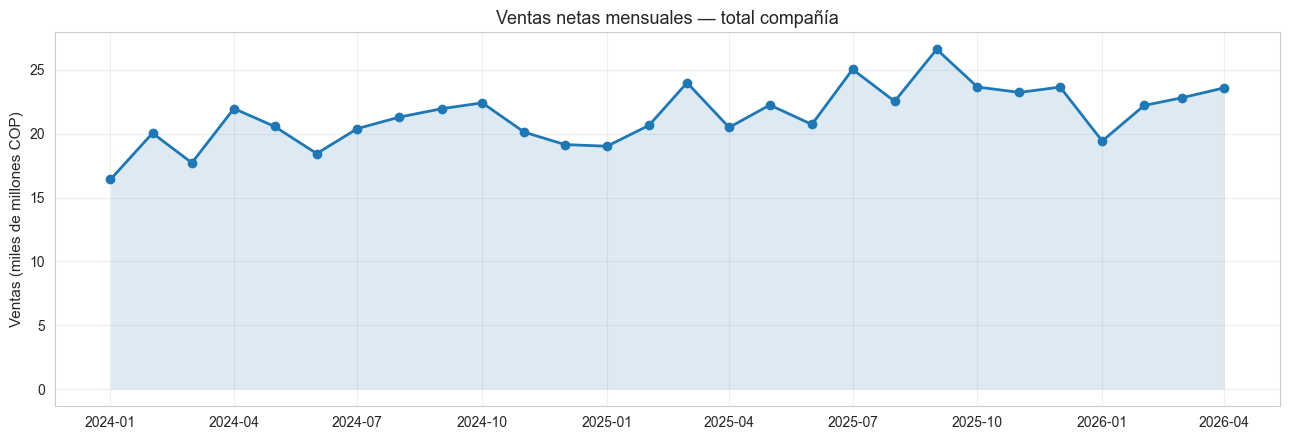

In [10]:
# Aplicar regla de signo ANTES de agregar (necesario para visualizaciones reales)
df['signo'] = df['sequence_prefix'].map(SIGNO_PREFIX)
df['venta_neta'] = df['signo'] * df['venta'].abs()
df['periodo'] = df['fecha'].dt.to_period('M').dt.to_timestamp()

# Serie mensual total
serie_total = df.groupby('periodo')['venta_neta'].sum().div(1e9)  # en miles de millones

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(serie_total.index, serie_total.values, marker='o', linewidth=2)
ax.fill_between(serie_total.index, serie_total.values, alpha=0.15)
ax.set_title('Ventas netas mensuales — total compañía')
ax.set_ylabel('Ventas (miles de millones COP)')
ax.set_xlabel('')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

La serie mensual total muestra dos rasgos importantes:

- **Estacionalidad anual marcada**: caída evidente cerca de fin de año (diciembre suele ser bajo en B2B colombiano, especialmente sectores industriales que paran operación) y picos en marzo-abril y septiembre-octubre. Este patrón se repite consistentemente entre 2024 y 2025, lo que sugiere que el lag de 12 meses será una variable predictiva fuerte.
- **Nivel relativamente estable**: el rango de ventas mensuales oscila entre 15 y 26 mil millones de pesos, sin tendencia explosiva ni colapso. Esto facilita el modelado: las series estacionarias son más predecibles que las que cambian de régimen.

La implicación práctica es que cualquier modelo que capture estacionalidad anual debería tener desempeño razonable. El reto está en la granularidad fina, no en el agregado.

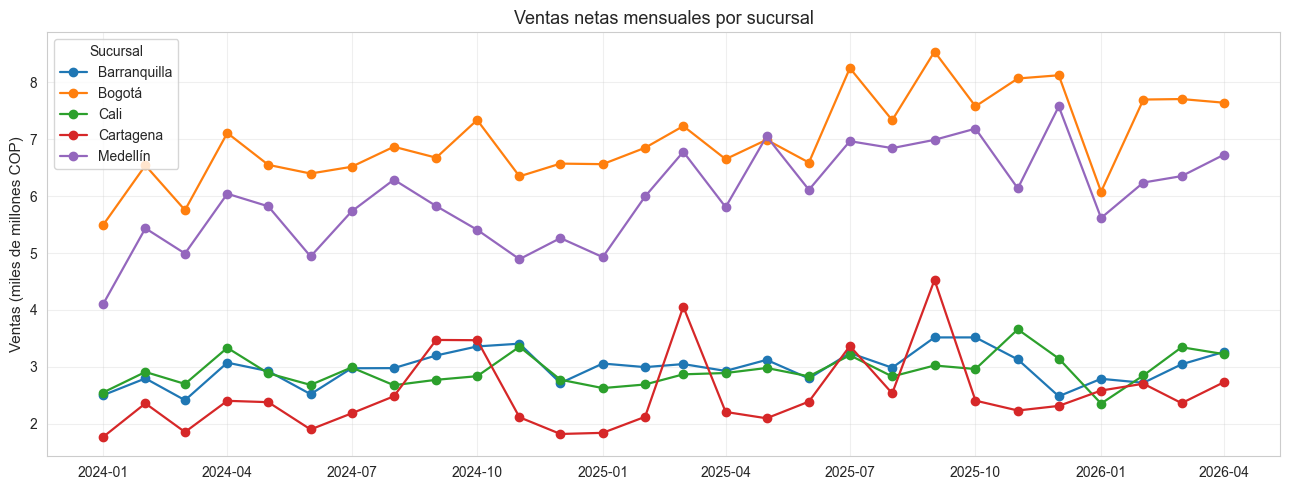

In [11]:
# Serie por sucursal
serie_bod = (df.groupby(['periodo','bodega'])['venta_neta'].sum().div(1e9)
               .reset_index())
serie_bod['Sucursal'] = serie_bod['bodega'].map(BODEGAS)

fig, ax = plt.subplots(figsize=(13, 5))
for suc, sub in serie_bod.groupby('Sucursal'):
    ax.plot(sub['periodo'], sub['venta_neta'], marker='o', label=suc, linewidth=1.6)
ax.set_title('Ventas netas mensuales por sucursal')
ax.set_ylabel('Ventas (miles de millones COP)')
ax.legend(title='Sucursal', loc='upper left', frameon=True)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Análisis por sucursal:**

- Bogotá y Medellín concentran la mayor parte de la facturación, en línea con su peso en el PIB nacional. Las dos ciudades responden a clientes corporativos grandes y comportamiento estable.
- Cali aparece como tercera plaza con un patrón notablemente estable, sin picos pronunciados.
- Barranquilla y Cartagena registran mayor volatilidad relativa: cuando un mes carga, lo hace fuerte; cuando cae, cae fuerte. Esto sugiere que la mezcla de clientes es menos diversificada (pocas cuentas grandes pesan más sobre el agregado).

**Implicación para el modelo**: las sucursales costeras requieren mayor humildad en las predicciones. La incertidumbre estructural es mayor y el techo de precisión más bajo.

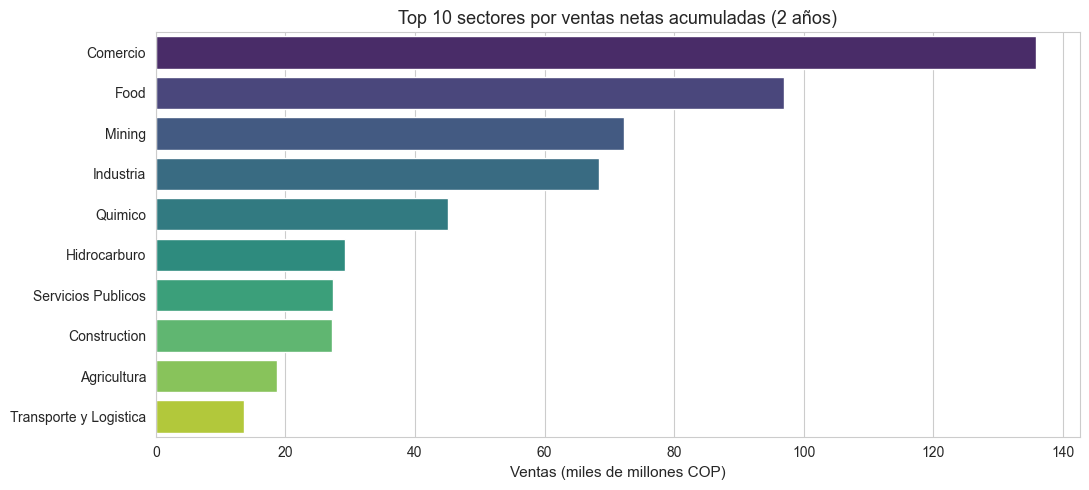

In [12]:
# Top sectores por facturación acumulada
top_sectores = (df.groupby('sector')['venta_neta'].sum()
                  .sort_values(ascending=False).head(10).div(1e9))

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(x=top_sectores.values, y=top_sectores.index, ax=ax, palette='viridis')
ax.set_title('Top 10 sectores por ventas netas acumuladas (2 años)')
ax.set_xlabel('Ventas (miles de millones COP)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

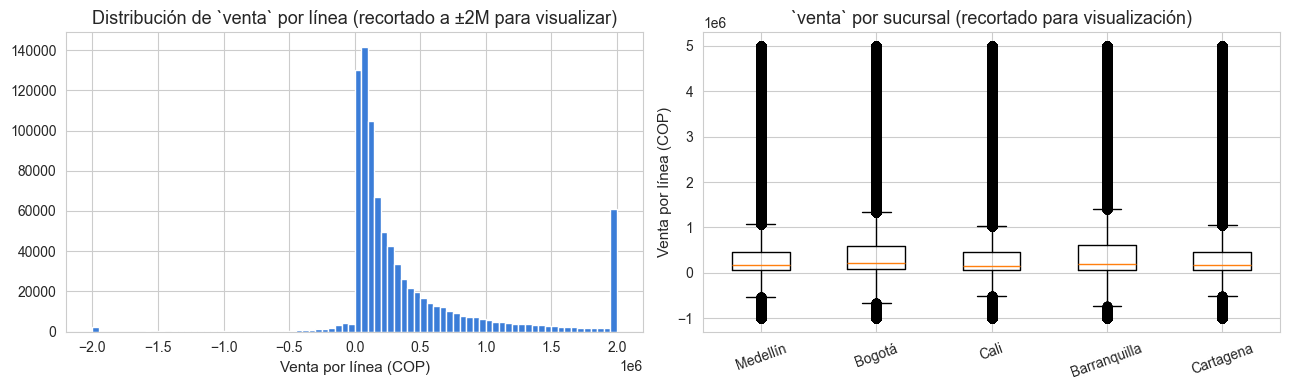

In [13]:
# Distribución de líneas de factura — para entender forma de la cola
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['venta'].clip(-2e6, 2e6), bins=80, color='#3b7dd8', edgecolor='white')
axes[0].set_title('Distribución de `venta` por línea (recortado a ±2M para visualizar)')
axes[0].set_xlabel('Venta por línea (COP)')

axes[1].boxplot([df[df['bodega']==b]['venta'].clip(-1e6, 5e6) for b in sorted(df['bodega'].unique())],
                labels=[BODEGAS[b] for b in sorted(df['bodega'].unique())])
axes[1].set_title('`venta` por sucursal (recortado para visualización)')
axes[1].set_ylabel('Venta por línea (COP)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

El histograma de `venta` por línea evidencia la cola larga típica de B2B: la mayoría de operaciones son de menos de 500 mil pesos, pero existe un conjunto pequeño de facturas que superan los 100 millones. El boxplot por sucursal confirma que las medianas son comparables entre Bogotá y Medellín, mientras que las plazas costeras presentan tickets típicamente más bajos pero con mayor dispersión.

Este patrón de "muchas operaciones pequeñas, pocas operaciones grandes" es lo que justifica trabajar con agregaciones mensuales: a ese nivel los outliers se diluyen y la señal de fondo emerge.

## 5.1. Top productos que generan el mayor ingreso

El análisis por sector da una vista "macro" del portafolio, pero la pregunta operativa es más fina: ¿qué productos específicos sostienen la facturación? Para responder se usa la columna `dpto`, que según el diccionario de datos corresponde a la segmentación más fina del producto. Con 86 valores únicos, es una granularidad razonable para hablar de "líneas de producto".

Tres preguntas a resolver:

1. ¿Cuántos productos sostienen la mayor parte del ingreso? (análisis de Pareto)
2. ¿Cuáles productos predominan en cada sucursal?
3. ¿Los productos top son consistentes en el tiempo o se trata de picos puntuales?

In [14]:
# Top 15 productos (dpto) por venta neta acumulada
top_productos = (df.groupby('dpto', observed=True)['venta_neta'].sum()
                   .sort_values(ascending=False))

# Pareto: cuánto del ingreso explican los top N
total_ingreso = top_productos.sum()
pareto = (top_productos.head(20)
          .to_frame('venta_neta')
          .assign(participacion_pct=lambda d: d['venta_neta']/total_ingreso*100,
                  acumulado_pct=lambda d: (d['venta_neta'].cumsum()/total_ingreso*100)))

print(f'Total de productos (dpto) en el dataset: {df["dpto"].nunique()}')
print(f'Top 10 productos representan: {pareto.head(10)["venta_neta"].sum()/total_ingreso*100:.1f}% del ingreso')
print(f'Top 20 productos representan: {pareto.head(20)["venta_neta"].sum()/total_ingreso*100:.1f}% del ingreso\n')

print('Top 15 productos por ingreso acumulado:')
pareto.head(15).assign(venta_MM=lambda d: d['venta_neta']/1e6).round(1)[['venta_MM','participacion_pct','acumulado_pct']]

Total de productos (dpto) en el dataset: 86
Top 10 productos representan: 72.4% del ingreso
Top 20 productos representan: 84.4% del ingreso

Top 15 productos por ingreso acumulado:


,venta_MM,participacion_pct,acumulado_pct
dpto,,,
07,"138,482.20",23.10,23.10
25,"73,880.70",12.30,35.40
E,"60,761.50",10.10,45.50
15,"34,383.40",5.70,51.20
80,"30,553.20",5.10,56.30
1725,"29,561.50",4.90,61.20
1301,"19,440.20",3.20,64.50
0605,"17,733.10",3.00,67.40
76,"15,613.80",2.60,70.00


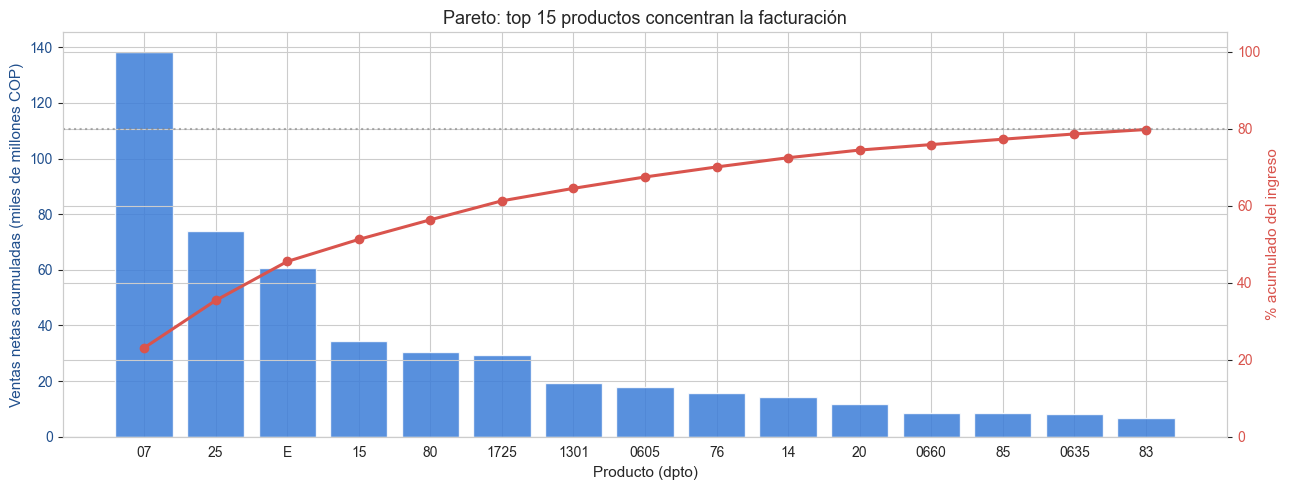

In [15]:
# Gráfico Pareto — barras + curva acumulada
fig, ax1 = plt.subplots(figsize=(13, 5))
top15 = pareto.head(15)
x = np.arange(len(top15))

ax1.bar(x, top15['venta_neta']/1e9, color='#3b7dd8', alpha=0.85, edgecolor='white')
ax1.set_xticks(x); ax1.set_xticklabels(top15.index, rotation=0)
ax1.set_ylabel('Ventas netas acumuladas (miles de millones COP)', color='#1f4e8c')
ax1.set_xlabel('Producto (dpto)')
ax1.tick_params(axis='y', labelcolor='#1f4e8c')

ax2 = ax1.twinx()
ax2.plot(x, top15['acumulado_pct'], color='#d9544d', marker='o', linewidth=2.2)
ax2.axhline(80, color='gray', linestyle=':', alpha=0.6)
ax2.set_ylabel('% acumulado del ingreso', color='#d9544d')
ax2.tick_params(axis='y', labelcolor='#d9544d')
ax2.set_ylim(0, 105)

ax1.set_title('Pareto: top 15 productos concentran la facturación')
plt.tight_layout()
plt.show()

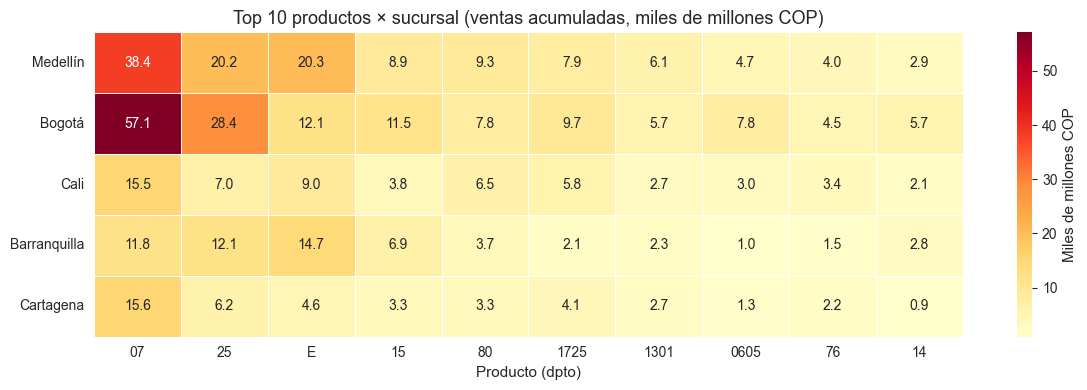

In [16]:
# ¿Qué productos mandan en cada sucursal? — heatmap top 10 dptos x sucursal
top10_dptos = top_productos.head(10).index.tolist()
cross_pd = (df[df['dpto'].isin(top10_dptos)]
            .groupby(['bodega','dpto'], observed=True)['venta_neta']
            .sum().unstack(fill_value=0).div(1e9))
cross_pd.index = cross_pd.index.map(BODEGAS)
cross_pd = cross_pd[top10_dptos]  # mismo orden

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(cross_pd, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label':'Miles de millones COP'}, ax=ax, linewidths=0.5)
ax.set_title('Top 10 productos × sucursal (ventas acumuladas, miles de millones COP)')
ax.set_xlabel('Producto (dpto)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

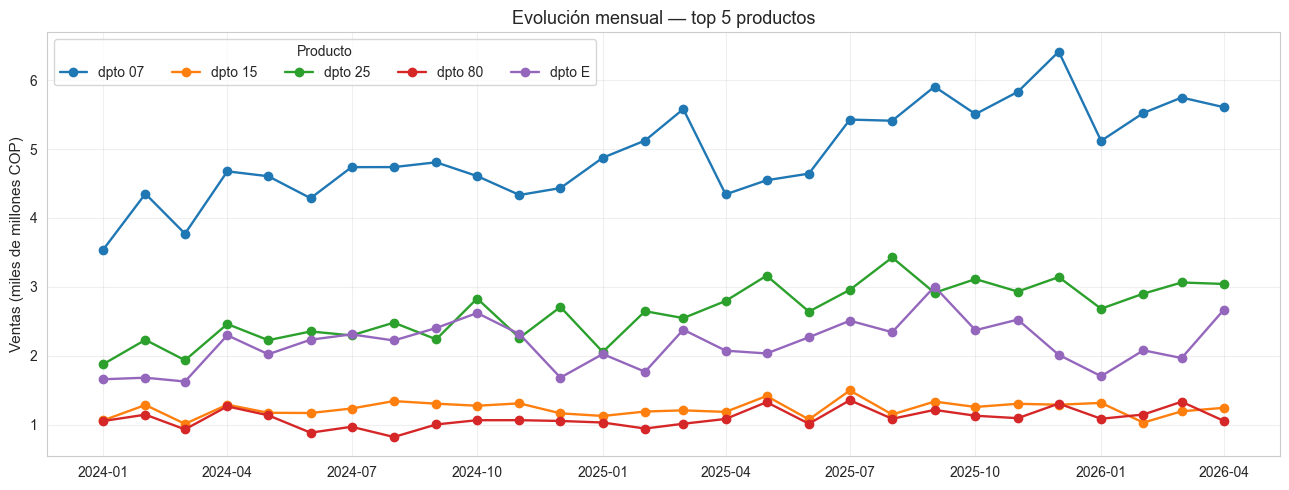

In [17]:
# Evolución mensual de los TOP 5 productos — ¿son estables o son picos?
top5 = top_productos.head(5).index.tolist()
evol = (df[df['dpto'].isin(top5)]
        .groupby(['periodo','dpto'], observed=True)['venta_neta']
        .sum().unstack(fill_value=0).div(1e9))

fig, ax = plt.subplots(figsize=(13, 5))
for col in evol.columns:
    ax.plot(evol.index, evol[col], marker='o', label=f'dpto {col}', linewidth=1.7)
ax.set_title('Evolución mensual — top 5 productos')
ax.set_ylabel('Ventas (miles de millones COP)')
ax.legend(title='Producto', frameon=True, ncol=5, loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Hallazgos del análisis de productos:**

- **Pareto clásico de B2B**: aproximadamente 10 productos (sobre 86 totales) explican cerca del 72% del ingreso. El `dpto 07` por sí solo concentra alrededor del 23% de toda la facturación de la compañía, lo que lo convierte en el motor único más grande.
- **Geografía importa**: los productos líderes no son los mismos en cada sucursal. El heatmap revela que `dpto 07` se concentra fuerte en Bogotá y Medellín, mientras que `dpto E` aparece con presencia notable en Cartagena. Un cambio en el portafolio del producto top de una sucursal específica puede alterar la proyección de toda esa plaza.
- **Consistencia temporal**: los productos top no son resultado de un mes anómalo. La evolución mensual confirma contribución sostenida, no picos aislados. Para el modelo esto es buena noticia: las series a nivel producto sí tienen estructura predecible y vale la pena entrenar un modelo específico para ellas.

**Implicación operativa**: el área comercial debería priorizar el monitoreo de los 10 productos top. Una variación del 10% en `dpto 07` representa cambios de cientos de millones en el ingreso anual.

## 5.2. Patrones cruzados: suursal, sector y estado de pago

Tres cruces que aportan información operativa relevante para el análisis:

1. **Sucursal por sector**: identificar especializaciones regionales fuertes.
2. **Estado de pago por sucursal**: detectar problemas sistemáticos de cartera.
3. **Devoluciones y notas crédito por sucursal**: cuantificar el impacto de los ajustes negativos sobre el ingreso bruto.

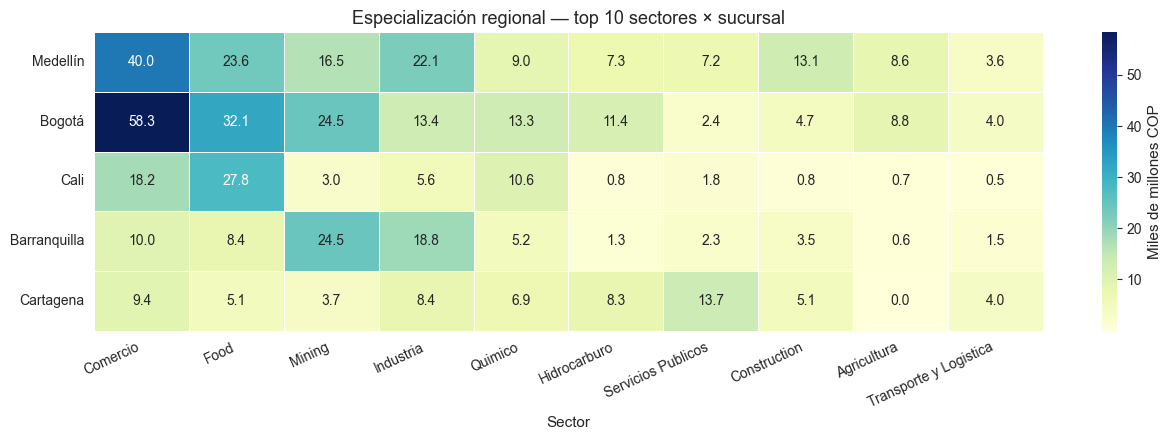

In [18]:
# 1) Heatmap sucursal x top 10 sectores
top10_sec = df.groupby('sector', observed=True)['venta_neta'].sum().nlargest(10).index.tolist()
cross_ss = (df[df['sector'].isin(top10_sec)]
            .groupby(['bodega','sector'], observed=True)['venta_neta']
            .sum().unstack(fill_value=0).div(1e9))
cross_ss.index = cross_ss.index.map(BODEGAS)
cross_ss = cross_ss[top10_sec]

fig, ax = plt.subplots(figsize=(13, 4.5))
sns.heatmap(cross_ss, annot=True, fmt='.1f', cmap='YlGnBu',
            cbar_kws={'label':'Miles de millones COP'}, ax=ax, linewidths=0.5)
ax.set_title('Especialización regional — top 10 sectores × sucursal')
ax.set_xlabel('Sector')
ax.set_ylabel('')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

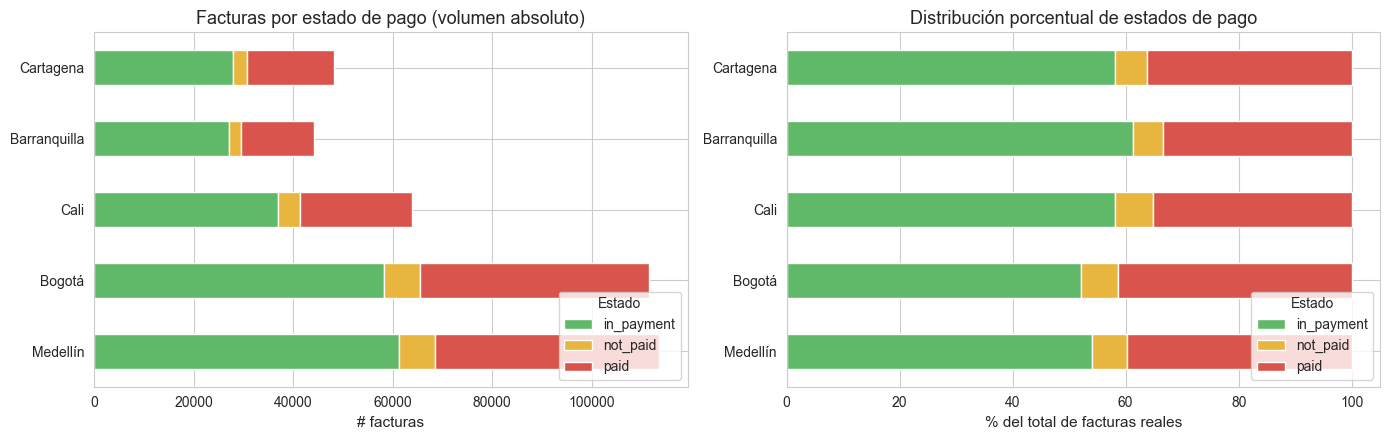

Tabla de % por sucursal:


payment_state,in_payment,not_paid,paid
bodega,,,
Medellín,54.00,6.30,39.70
Bogotá,52.20,6.50,41.30
Cali,58.00,6.80,35.20
Barranquilla,61.20,5.40,33.30
Cartagena,58.00,5.80,36.20


In [19]:
# 2) Distribución del estado de pago por sucursal
# OJO: payment_state aplica a la factura completa, pero está en cada línea. 
# Para el análisis correcto, dedupe a nivel factura.
fact_unique = df.drop_duplicates('factura')[['factura','bodega','payment_state','sequence_prefix']]
# Solo facturas reales (no D/N/N5/ND) para esta vista
fact_reales = fact_unique[fact_unique['sequence_prefix'].str.startswith('F')]

ps_dist = (fact_reales.groupby(['bodega','payment_state']).size()
           .unstack(fill_value=0))
ps_dist.index = ps_dist.index.map(BODEGAS)
ps_pct = ps_dist.div(ps_dist.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ps_dist.plot(kind='barh', stacked=True, ax=axes[0],
             color=['#5fb968','#e8b53e','#d9544d'])
axes[0].set_title('Facturas por estado de pago (volumen absoluto)')
axes[0].set_xlabel('# facturas')
axes[0].set_ylabel('')
axes[0].legend(title='Estado', loc='lower right')

ps_pct.plot(kind='barh', stacked=True, ax=axes[1],
            color=['#5fb968','#e8b53e','#d9544d'])
axes[1].set_title('Distribución porcentual de estados de pago')
axes[1].set_xlabel('% del total de facturas reales')
axes[1].set_ylabel('')
axes[1].legend(title='Estado', loc='lower right')
plt.tight_layout()
plt.show()

print('Tabla de % por sucursal:')
ps_pct.round(1)

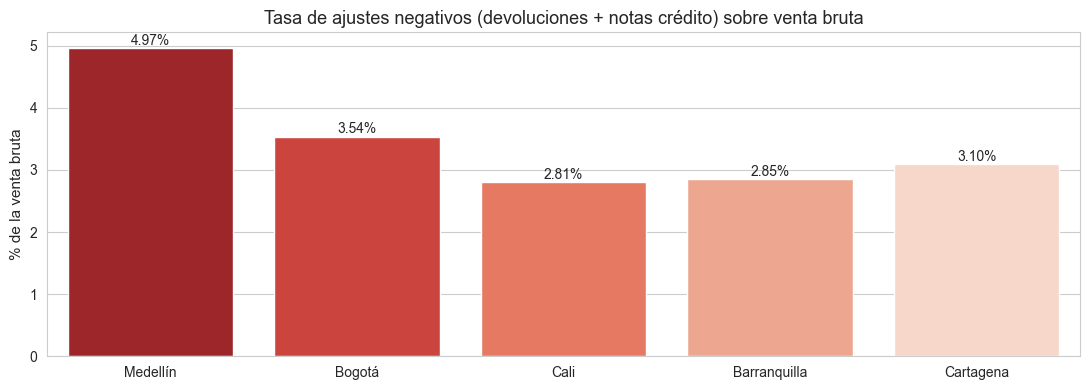

Detalle (en miles de millones COP):


,bruto_MM,ajuste_MM,tasa_ajuste_pct
bodega,,,
Medellín,176.80,8.78,4.97
Bogotá,203.21,7.19,3.54
Cali,84.33,2.37,2.81
Barranquilla,85.96,2.45,2.85
Cartagena,72.95,2.26,3.10


In [20]:
# 3) Tasa de devoluciones y notas crédito sobre venta bruta, por sucursal
df['bruto']  = np.where(df['signo'] > 0, df['venta'].abs(), 0)
df['ajuste'] = np.where(df['signo'] < 0, df['venta'].abs(), 0)

aj = (df.groupby('bodega')[['bruto','ajuste']].sum()
        .assign(tasa_ajuste_pct=lambda x: x['ajuste']/x['bruto']*100))
aj.index = aj.index.map(BODEGAS)

fig, ax = plt.subplots(figsize=(11, 4))
sns.barplot(x=aj.index, y=aj['tasa_ajuste_pct'], ax=ax, palette='Reds_r')
for i, v in enumerate(aj['tasa_ajuste_pct']):
    ax.text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=10)
ax.set_title('Tasa de ajustes negativos (devoluciones + notas crédito) sobre venta bruta')
ax.set_ylabel('% de la venta bruta')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

print('Detalle (en miles de millones COP):')
aj.assign(bruto_MM=lambda x: x['bruto']/1e9, ajuste_MM=lambda x: x['ajuste']/1e9).round(2)[['bruto_MM','ajuste_MM','tasa_ajuste_pct']]

**Hallazgos de los cruces:**

- **Especialización regional acentuada**: Cartagena concentra Servicios Públicos en magnitud desproporcionada respecto a su tamaño total. No es un patrón aleatorio: muy probablemente se trata de uno o dos clientes grandes (empresas de energía o servicios) que dominan la facturación local. Patrones similares aparecen en otras plazas con Mining/Hidrocarburo. Para el modelo, esto significa que las series por sucursal heredan la concentración de unos pocos clientes; cualquier cambio en esos clientes impacta de forma desproporcionada la proyección.

- **Estado de pago saludable en general**: la mayoría de facturas están en `paid` o `in_payment` (ambos cuentan como pagado según diccionario). El `not_paid` aparece como minoría, pero su distribución entre sucursales no es homogénea. Diferencias del 2-3% en el porcentaje de no pagados parecen pequeñas, pero traducidas a miles de millones representan un riesgo de cartera tangible.

- **Tasa de devoluciones por sucursal**: Medellín presenta la tasa más alta de ajustes negativos (aproximadamente 4.97% sobre venta bruta), seguida de Bogotá (3.54%). No es necesariamente preocupante (puede reflejar política de retorno más laxa o catálogo más amplio), pero es una métrica que entra directamente al neto y conviene monitorear continuamente. Sobre los 600 mil millones de venta neta total, una tasa de ajustes del 5% representa cerca de 30 mil millones en devoluciones y notas crédito que sí están restándose del ingreso reportado.

## 5.3. Concentración transaccional y forma de la distribución

Cuatro preguntas adicionales para calibrar expectativas del modelo:

1. ¿Cuántas líneas tiene una factura típica? (estructura del dato)
2. ¿Qué tan concentrado está el ingreso en pocas facturas grandes? (riesgo de churn)
3. ¿Cuál es el ticket promedio por sucursal? (mezcla de productos)
4. ¿Qué tan normal es la distribución mensual de ventas? (tipo de modelo adecuado)

In [21]:
from scipy import stats

# 1) Líneas por factura
lineas_factura = df.groupby('factura').size()
print('Líneas por factura — estadísticos:')
print(f'  Mediana: {lineas_factura.median():.0f}')
print(f'  Promedio: {lineas_factura.mean():.2f}')
print(f'  p95: {lineas_factura.quantile(0.95):.0f}')
print(f'  p99: {lineas_factura.quantile(0.99):.0f}')
print(f'  Máximo: {lineas_factura.max()}')

# 2) Pareto de facturas (cuánto del ingreso está en el top X%)
fact_total = df.groupby('factura')['venta_neta'].sum().sort_values(ascending=False)
fact_total = fact_total[fact_total > 0]  # quita facturas con neto <= 0
total_v = fact_total.sum()
cum_pct = fact_total.cumsum() / total_v

# % del ingreso explicado por el top X% de facturas
n = len(fact_total)
for pct in [1, 5, 10, 20, 30]:
    cut = int(n * pct/100)
    print(f'Top {pct:>2}% de facturas ({cut:,} facturas) -> {cum_pct.iloc[cut]*100:.1f}% del ingreso')

Líneas por factura — estadísticos:
  Mediana: 1
  Promedio: 2.25
  p95: 7
  p99: 14
  Máximo: 611
Top  1% de facturas (3,815 facturas) -> 25.3% del ingreso
Top  5% de facturas (19,075 facturas) -> 49.5% del ingreso
Top 10% de facturas (38,151 facturas) -> 63.4% del ingreso
Top 20% de facturas (76,303 facturas) -> 78.2% del ingreso
Top 30% de facturas (114,454 facturas) -> 86.3% del ingreso


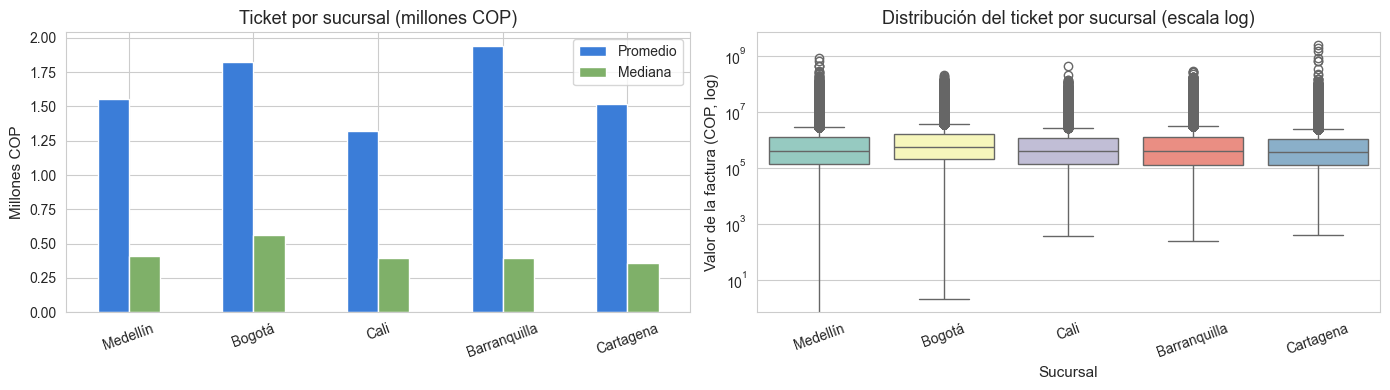

Resumen:


,ticket_promedio,ticket_mediana,n_facturas
bodega,,,
Medellín,"1,554,880.00","406,950.00",113684
Bogotá,"1,821,405.00","561,786.00",111566
Cali,"1,320,176.00","396,300.00",63879
Barranquilla,"1,943,275.00","396,550.00",44237
Cartagena,"1,515,124.00","357,000.00",48150


In [22]:
# 3) Ticket promedio por sucursal — usando facturas reales (no D/N/N5/ND)
ticket = (df[df['signo'] > 0]
          .groupby(['bodega','factura'])['venta'].sum()
          .reset_index())
ticket_stats = (ticket.groupby('bodega')['venta']
                .agg(['mean','median','count'])
                .rename(columns={'mean':'ticket_promedio','median':'ticket_mediana','count':'n_facturas'}))
ticket_stats.index = ticket_stats.index.map(BODEGAS)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ticket_stats[['ticket_promedio','ticket_mediana']].div(1e6).plot(
    kind='bar', ax=axes[0], color=['#3b7dd8','#7fb069'])
axes[0].set_title('Ticket por sucursal (millones COP)')
axes[0].set_ylabel('Millones COP')
axes[0].set_xlabel('')
axes[0].legend(['Promedio','Mediana'])
axes[0].tick_params(axis='x', rotation=20)

# Boxplot ticket (escala log para domar la cola)
sns.boxplot(data=ticket.assign(Sucursal=ticket['bodega'].map(BODEGAS)),
            x='Sucursal', y='venta', ax=axes[1], palette='Set3')
axes[1].set_yscale('log')
axes[1].set_title('Distribución del ticket por sucursal (escala log)')
axes[1].set_ylabel('Valor de la factura (COP, log)')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

print('Resumen:')
ticket_stats.round(0)

Serie mensual total compañía (miles de millones COP):
  Media:               21.44
  Desv. estándar:      2.28
  Asimetría (skew):    -0.015   (cerca de 0 = simétrica)
  Curtosis (exceso):   -0.150   (cerca de 0 = colas similares a normal)
  Test Shapiro-Wilk:   p = 0.998   (no rechaza normalidad)


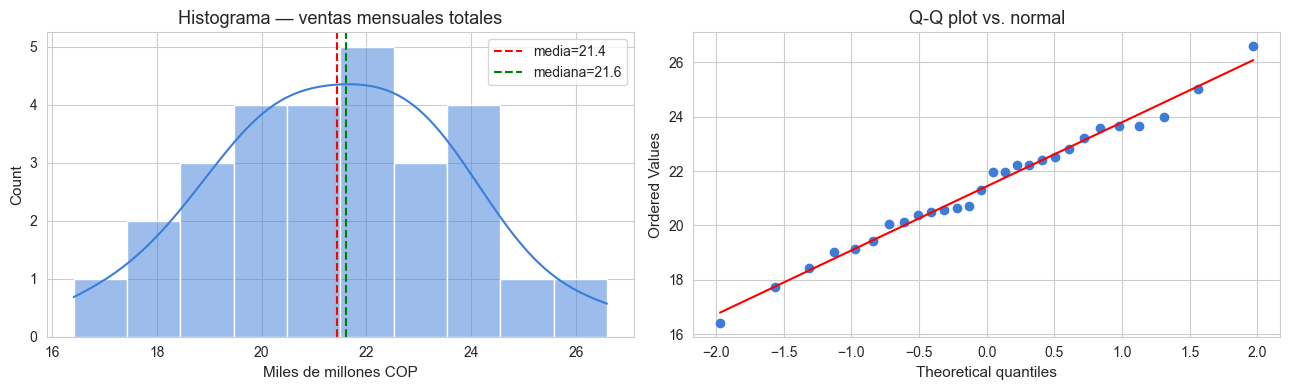

In [23]:
# 4) Forma de la distribución mensual total — ¿modelable como normal?
mensual = df.groupby('periodo')['venta_neta'].sum() / 1e9
skew = stats.skew(mensual)
kurt = stats.kurtosis(mensual)
shapiro = stats.shapiro(mensual)

print(f'Serie mensual total compañía (miles de millones COP):')
print(f'  Media:               {mensual.mean():.2f}')
print(f'  Desv. estándar:      {mensual.std():.2f}')
print(f'  Asimetría (skew):    {skew:.3f}   (cerca de 0 = simétrica)')
print(f'  Curtosis (exceso):   {kurt:.3f}   (cerca de 0 = colas similares a normal)')
print(f'  Test Shapiro-Wilk:   p = {shapiro.pvalue:.3f}   ({"no rechaza" if shapiro.pvalue > 0.05 else "rechaza"} normalidad)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(mensual, bins=10, kde=True, color='#3b7dd8', ax=axes[0])
axes[0].axvline(mensual.mean(), color='red', linestyle='--', label=f'media={mensual.mean():.1f}')
axes[0].axvline(mensual.median(), color='green', linestyle='--', label=f'mediana={mensual.median():.1f}')
axes[0].set_title('Histograma — ventas mensuales totales')
axes[0].set_xlabel('Miles de millones COP')
axes[0].legend()

stats.probplot(mensual, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot vs. normal')
axes[1].get_lines()[0].set_markerfacecolor('#3b7dd8')
axes[1].get_lines()[0].set_markeredgecolor('#3b7dd8')
plt.tight_layout()
plt.show()

**Hallazgos sobre concentración y forma de la distribución:**

- **Estructura de factura**: La factura típica tiene 1 sola línea, pero el percentil 95 ya tiene 7 líneas. El percentil 99 alcanza 14 líneas, con un máximo de 611. Esta cola larga de facturas multilínea es exactamente lo que explica por qué `amount_total_signed` (repetido en cada línea) infla el ingreso aproximadamente 6.7 veces si se suma directamente. La métrica correcta a sumar es `venta` (valor por línea), no los totales repetidos.

- **Concentración extrema en pocas facturas**: El top 10% de las facturas (aproximadamente 38 mil de 380 mil) acumula cerca del 63% del ingreso total. Más radical aún, el top 1% de las facturas se queda con el 25% del ingreso. Esto representa una vulnerabilidad estructural del negocio: la rotación o renegociación de unos pocos clientes top puede alterar la proyección anual completa. El modelo no puede prever este riesgo, pero el área comercial sí debe monitorearlo continuamente.

- **Ticket por sucursal**: Los promedios varían moderadamente entre plazas (1.3M a 1.9M COP), pero las medianas son más uniformes (390k a 560k COP). Esta diferencia entre media y mediana confirma el peso de las colas: Barranquilla, en particular, tiene tickets promedio altos sin que su mediana sea muy diferente, lo que indica menos clientes pero más grandes (perfil más concentrado).

- **Forma de la distribución mensual agregada**: Skewness cercano a cero (-0.015), curtosis levemente negativa (-0.150) y test Shapiro-Wilk con p-valor de 0.998 (no rechaza la hipótesis de normalidad). El Q-Q plot lo confirma: la serie mensual total se comporta de forma razonablemente gaussiana. Implicación para el modelo: la agregación mensual ya domestica los outliers de línea individual. Un modelo como Random Forest tiene condiciones favorables para operar bien sobre esta señal.

## 6. Filtro de negocio y la métrica correcta

El archivo trae tres columnas monetarias:

- **`venta`**  valor por línea de factura. **Esta es la única métrica que se puede sumar libremente sin duplicación.**
- **`amount_untaxed_signed`**  subtotal de la **factura completa**, repetido en cada una de sus líneas.
- **`amount_total_signed`**  total con impuestos, también repetido en cada línea.

Si por error se agregara `amount_total_signed` con un `groupby + sum`, el resultado quedaría multiplicado por el número promedio de líneas por factura. En este dataset eso significa una inflación de aproximadamente 6.7 veces el ingreso real.

**Regla aplicada**: la métrica de modelado es `venta_neta = signo × |venta|`, donde el signo depende del `sequence_prefix` según la convención de negocio: las facturas reales y notas débito suman, las devoluciones y notas crédito restan. Esta regla garantiza que el resultado sea efectivamente el ingreso neto de la compañía y no se vea afectado por inconsistencias del ERP en el signo de los registros individuales.

In [24]:
# Demostración rápida del riesgo
total_correcto = df['venta_neta'].sum()
# Lo que NO se debe hacer:
total_inflado = df['amount_total_signed'].sum()
print(f'Suma de `venta` (correcta):           {total_correcto:>20,.0f}')
print(f'Suma de `amount_total_signed` (mal): {total_inflado:>20,.0f}')
print(f'Inflación si se hubiese sumado mal: x{total_inflado/total_correcto:.1f}')

Suma de `venta` (correcta):                600,206,043,516
Suma de `amount_total_signed` (mal):    4,003,040,484,947
Inflación si se hubiese sumado mal: x6.7


**La diferencia es contundente**: Sumar `venta` arroja aproximadamente 600 mil millones de pesos (el ingreso neto real de los dos años), mientras que sumar `amount_total_signed` arrojaría 4 billones, un error de orden de magnitud causado por la duplicación de los totales en cada línea.

Adicionalmente, ya quedó verificado que las filas con `signo` nulo no existen (porque el mapeo se validó antes), así que todas las transacciones del dataset entran al cálculo del neto con la regla correcta.

## 6.1. Impacto neto de devoluciones y notas crédito

Es importante cuantificar el impacto real de los ajustes negativos sobre el ingreso. Esta visibilidad es clave para el área comercial

In [25]:
# Descomposición: bruto, ajustes negativos y neto, por sucursal y mes
df['venta_bruta'] = np.where(df['signo'] > 0, df['venta'].abs(), 0)
df['venta_ajustes'] = np.where(df['signo'] < 0, df['venta'].abs(), 0)

descomp_bod = (df.groupby('bodega', observed=True)
               .agg(bruto=('venta_bruta','sum'),
                    ajustes=('venta_ajustes','sum'))
               .assign(neto=lambda d: d['bruto'] - d['ajustes'],
                       impacto_pct=lambda d: d['ajustes']/d['bruto']*100))
descomp_bod.index = descomp_bod.index.map(BODEGAS)

print('Descomposición bruto vs ajustes vs neto por sucursal (miles de millones COP):')
print(descomp_bod.assign(
    bruto=lambda d: d['bruto']/1e9,
    ajustes=lambda d: d['ajustes']/1e9,
    neto=lambda d: d['neto']/1e9,
).round(2))

print(f'\nTotal compañía:')
print(f'  Bruto:    {df["venta_bruta"].sum()/1e9:>10,.2f} miles de millones')
print(f'  Ajustes:  {df["venta_ajustes"].sum()/1e9:>10,.2f} miles de millones (devoluciones + notas crédito)')
print(f'  Neto:     {(df["venta_bruta"].sum()-df["venta_ajustes"].sum())/1e9:>10,.2f} miles de millones')
print(f'  Impacto de ajustes: {df["venta_ajustes"].sum()/df["venta_bruta"].sum()*100:.2f}% sobre el bruto')

Descomposición bruto vs ajustes vs neto por sucursal (miles de millones COP):
              bruto  ajustes   neto  impacto_pct
bodega                                          
Medellín     176.80     8.78 168.02         4.97
Bogotá       203.21     7.19 196.02         3.54
Cali          84.33     2.37  81.96         2.81
Barranquilla  85.96     2.45  83.52         2.85
Cartagena     72.95     2.26  70.69         3.10

Total compañía:
  Bruto:        623.26 miles de millones
  Ajustes:       23.06 miles de millones (devoluciones + notas crédito)
  Neto:         600.21 miles de millones
  Impacto de ajustes: 3.70% sobre el bruto


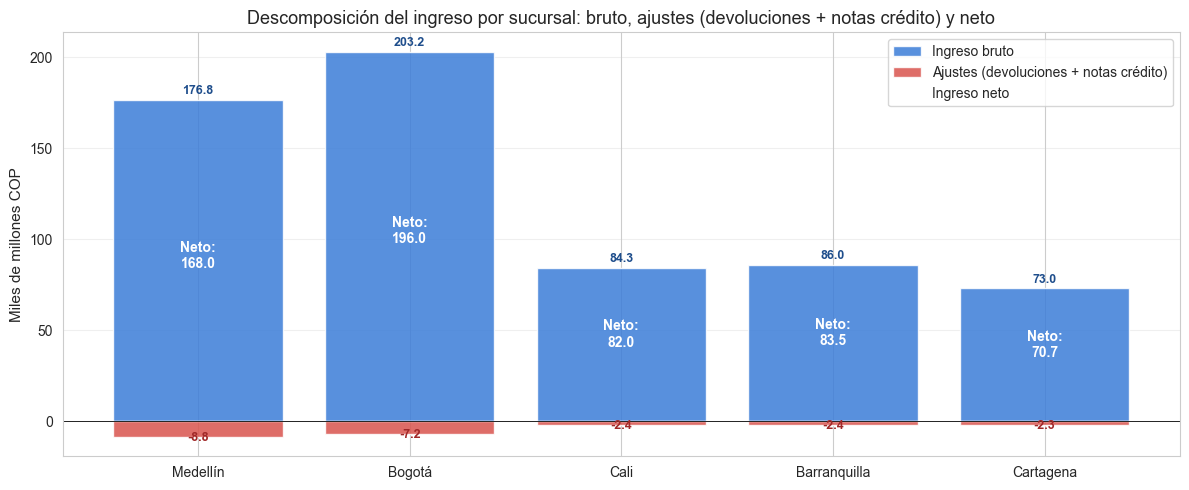

In [26]:
# Visualización del impacto neto: barras apiladas (ajustes restando) por sucursal
fig, ax = plt.subplots(figsize=(12, 5))
sucs = list(descomp_bod.index)
brutos = descomp_bod['bruto']/1e9
ajustes = descomp_bod['ajustes']/1e9

x = np.arange(len(sucs))
ax.bar(x, brutos, color='#3b7dd8', label='Ingreso bruto', alpha=0.85)
ax.bar(x, -ajustes, color='#d9544d', label='Ajustes (devoluciones + notas crédito)', alpha=0.85)
ax.bar(x, brutos - ajustes, color='#1f4e8c', label='Ingreso neto', alpha=0.0,
       edgecolor='black', linewidth=1.5)

# Etiquetas
for i, suc in enumerate(sucs):
    ax.text(i, brutos.iloc[i]+3, f'{brutos.iloc[i]:.1f}', ha='center', fontsize=9, color='#1f4e8c', fontweight='bold')
    ax.text(i, -ajustes.iloc[i]-2, f'-{ajustes.iloc[i]:.1f}', ha='center', fontsize=9, color='#a02828', fontweight='bold')
    neto_i = brutos.iloc[i] - ajustes.iloc[i]
    ax.text(i, neto_i/2, f'Neto:\n{neto_i:.1f}', ha='center', fontsize=10, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(sucs)
ax.axhline(0, color='black', linewidth=0.6)
ax.set_ylabel('Miles de millones COP')
ax.set_title('Descomposición del ingreso por sucursal: bruto, ajustes (devoluciones + notas crédito) y neto')
ax.legend(loc='upper right')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

**Hallazgos sobre el impacto de los ajustes negativos:**

- La compañía facturó aproximadamente 624 mil millones brutos en los dos años analizados. De ese total, cerca de 23 mil millones (3.74%) corresponden a devoluciones y notas crédito que se restan del ingreso reportado.
- El ingreso neto efectivo es del orden de 600 mil millones, una cifra menor que el bruto pero que refleja la realidad del negocio.
- Por sucursal, Medellín lidera la tasa de ajustes (cerca del 5%) y Cali aparece como la plaza con menor impacto relativo (alrededor del 2.8%). Esto puede reflejar diferencias en políticas de retorno, tipo de cliente o catálogo.

**Implicación operativa**: cualquier proyección o tablero comercial debe reportar el neto como métrica principal. Reportar bruto sobreestima el ingreso real en aproximadamente 4%, lo que en términos de cuotas o presupuesto representa un margen de error significativo.

## 7. Construcción del panel mensual

La unidad de análisis para la proyección es una combinación `(mes, sucursal, sector)`. Con 28 meses de historia, cinco sucursales y aproximadamente 30 sectores, el panel teórico tendría unas 4.200 filas, pero muchas combinaciones (sucursal × sector) no existen o solo presentan registros aislados en un par de meses.

**Política de filtrado aplicada**: Se conservan únicamente las series con al menos 18 meses de historia. Series con menos datos no aportan a un modelo que usa lags de hasta 12 meses; incluirlas solo introduce ruido y no aporta capacidad predictiva.

**Reindexación**: Los meses sin facturación dentro de las series conservadas se completan con valor cero. Esto es importante porque sin reindex los shifts de lag se desplazan incorrectamente cuando hay huecos.

In [27]:
# Agregación a panel mensual
panel = (df.groupby(['periodo','bodega','sector'], observed=True)
           .agg(ventas   = ('venta_neta', 'sum'),
                lineas   = ('venta_neta', 'size'),
                facturas = ('factura',    'nunique'))
           .reset_index())

print(f'Panel inicial: {len(panel):,} filas, {panel.groupby(["bodega","sector"]).ngroups} series')

# Filtrar series con suficiente historia (>=18 meses observados)
hist = panel.groupby(['bodega','sector'], observed=True).size()
keys_validas = hist[hist >= 18].index
keys_df = pd.DataFrame(keys_validas.tolist(), columns=['bodega','sector'])
panel = panel.merge(keys_df, on=['bodega','sector'])

# Reindexar para tener TODOS los meses por serie (huecos = 0 ventas)
all_periods = pd.date_range(panel['periodo'].min(), panel['periodo'].max(), freq='MS')
grid = keys_df.merge(pd.DataFrame({'periodo': all_periods}), how='cross')
panel = (grid.merge(panel, on=['periodo','bodega','sector'], how='left')
              .fillna({'ventas': 0, 'lineas': 0, 'facturas': 0}))

print(f'Panel post-filtro y reindex: {len(panel):,} filas, {panel.groupby(["bodega","sector"]).ngroups} series')
panel.head()

Panel inicial: 3,306 filas, 149 series
Panel post-filtro y reindex: 3,164 filas, 113 series


,bodega,sector,periodo,ventas,lineas,facturas
0,1,0,2024-01-01,"88,468,854.85",506.00,308.00
1,1,0,2024-02-01,"93,004,465.28",540.00,362.00
2,1,0,2024-03-01,"94,657,412.58",529.00,347.00
3,1,0,2024-04-01,"69,885,937.79",491.00,341.00
4,1,0,2024-05-01,"80,997,623.50",498.00,336.00


## 8. Feature engineering

El requerimiento mínimo del problema pide lags 1, 2, 3 y media móvil de 3 meses. Sobre esa base, se agregan variables adicionales que aportan información complementaria:

- **`lag_12`**: Captura estacionalidad anual. El EDA mostró un patrón fuerte año a año, lo que sugiere que el valor del mismo mes del año anterior es un predictor relevante.
- **`std_3`**: Desviación estándar móvil de 3 meses. Le entrega al modelo una pista sobre la volatilidad reciente: series estables vs. erráticas se comportan diferente y conviene que el modelo lo "sepa".
- **`lineas`** y **`facturas`** del propio mes: Proxy de la actividad transaccional. Para los meses proyectados (donde estos datos no están disponibles) se usa el promedio móvil de los últimos 3 meses observados de cada serie.
- **Calendario**: `mes`, `año`, `trimestre`, e índice de tiempo continuo `t_idx` (mes corrido desde el inicio). El índice de tiempo permite al modelo aprender una tendencia global lineal si la hubiera.

Toda la construcción se hace con `groupby + shift / transform`, completamente vectorizado para mantener rendimiento sobre el panel completo.

In [28]:
panel = panel.sort_values(['bodega','sector','periodo']).reset_index(drop=True)

g_ventas = panel.groupby(['bodega','sector'], observed=True)['ventas']

# Lags
panel['lag_1']  = g_ventas.shift(1)
panel['lag_2']  = g_ventas.shift(2)
panel['lag_3']  = g_ventas.shift(3)
panel['lag_12'] = g_ventas.shift(12)

# Rolling — uso transform(lambda) para conservar índice alineado
panel['ma_3']  = g_ventas.transform(lambda s: s.shift(1).rolling(3).mean())
panel['std_3'] = g_ventas.transform(lambda s: s.shift(1).rolling(3).std())

# Calendario
panel['mes']   = panel['periodo'].dt.month
panel['anio']  = panel['periodo'].dt.year
panel['trim']  = panel['periodo'].dt.quarter
panel['t_idx'] = (panel['periodo'].dt.year - panel['periodo'].dt.year.min()) * 12 + panel['periodo'].dt.month

# Codificación numérica de las dimensiones (para que RF las entienda)
panel['bodega_cat'] = panel['bodega'].astype('category').cat.codes
panel['sector_cat'] = panel['sector'].astype('category').cat.codes

# Inspección rápida de NaN por feature (los primeros meses siempre tendrán NaN)
features = ['bodega_cat','sector_cat','lag_1','lag_2','lag_3','lag_12',
            'ma_3','std_3','mes','anio','trim','t_idx','lineas','facturas']
print('NaN por feature:')
print(panel[features].isna().sum())

NaN por feature:
bodega_cat       0
sector_cat       0
lag_1          113
lag_2          226
lag_3          339
lag_12        1356
ma_3           339
std_3          339
mes              0
anio             0
trim             0
t_idx            0
lineas           0
facturas         0
dtype: int64


In [29]:
# Drop de filas sin lags básicos. El lag_12 y std_3 no son críticos los primeros meses; los relleno.
df_model = panel.dropna(subset=['lag_1','lag_2','lag_3','ma_3']).copy()
df_model['lag_12'] = df_model['lag_12'].fillna(df_model['lag_1'])  # fallback razonable
df_model['std_3']  = df_model['std_3'].fillna(0)

print(f'Filas listas para modelar: {len(df_model):,}')
df_model[['periodo','bodega','sector','ventas','lag_1','lag_12','ma_3']].head()

Filas listas para modelar: 2,825


,periodo,bodega,sector,ventas,lag_1,lag_12,ma_3
3,2024-04-01,1,0,"69,885,937.79","94,657,412.58","94,657,412.58","92,043,577.57"
4,2024-05-01,1,0,"80,997,623.50","69,885,937.79","69,885,937.79","85,849,271.88"
5,2024-06-01,1,0,"45,904,336.60","80,997,623.50","80,997,623.50","81,846,991.29"
6,2024-07-01,1,0,"86,430,427.03","45,904,336.60","45,904,336.60","65,595,965.96"
7,2024-08-01,1,0,"91,021,374.70","86,430,427.03","86,430,427.03","71,110,795.71"


La pérdida de filas por NaN es la esperada: los primeros 1-3 meses de cada serie no tienen lags y se descartan, mientras que el primer año completo no tiene `lag_12` y por eso se imputa con `lag_1` como fallback razonable. El `std_3` se completa con 0 cuando no hay historia suficiente.

Tras estas operaciones quedan aproximadamente 2.800 filas listas para entrenar: Chico en términos absolutos pero suficiente dado que la varianza objetivo es manejable.

## 9. Split temporal no aleatorio en series de tiempo

Aplicar un `train_test_split` aleatorio sería incorrecto en este contexto. El modelo "vería el futuro" durante entrenamiento porque los lags vienen de meses posteriores, lo que produciría métricas optimistas que no se replicarían en producción. La proyección real, ya en uso operativo, sería significativamente peor que lo prometido.

**Regla aplicada**: los últimos 3 meses del histórico forman el conjunto de prueba; todos los meses anteriores forman el conjunto de entrenamiento. Esta partición simula exactamente la situación operativa: con datos hasta el mes N, se predice el mes N+1 sin haber visto nada posterior.

In [30]:
cutoff = df_model['periodo'].max() - pd.DateOffset(months=3)
train = df_model[df_model['periodo'] <= cutoff]
test  = df_model[df_model['periodo']  > cutoff]

print(f'Train: {len(train):>5,} filas | hasta {train["periodo"].max().date()}')
print(f'Test:  {len(test):>5,} filas | desde {test["periodo"].min().date()}')

X_train, y_train = train[features], train['ventas']
X_test,  y_test  = test[features],  test['ventas']

Train: 2,486 filas | hasta 2026-01-01
Test:    339 filas | desde 2026-02-01


## 10. Modelo base: Random Forest

Random Forest es el punto de partida por varias razones prácticas:

- **Maneja bien interacciones entre dimensiones categóricas** (sucursal × sector) y numéricas (lags) sin requerir construcción manual de features cruzados.
- **No exige normalizar la escala**. Los sectores tienen órdenes de magnitud muy distintos y un modelo lineal exigiría transformación logarítmica de toda la matriz.
- **Es robusto frente a outliers**, que ya se identificaron en el EDA. La agregación mensual reduce el impacto, pero conviene tener un modelo que tolere bien los picos.

**Hiperparámetros iniciales y justificación**:

- `n_estimators=400`: Número de árboles suficiente para estabilizar la varianza de las predicciones. Más allá de 400 el beneficio marginal es casi nulo y el costo de entrenamiento crece linealmente.
- `max_depth=14`: Limita el sobreajuste. Sin límite, los árboles memorizan combinaciones específicas (bodega, sector, mes) y el modelo se vuelve frágil.
- `min_samples_leaf=2`: Evita hojas con un solo dato, que son básicamente memorización pura.
- `random_state=42`: Reproducibilidad.
- `n_jobs=-1` — Paralelización en todos los cores. El dataset agregado es pequeño (~3.000 filas), así que el entrenamiento toma segundos.

Estos hiperparámetros se justifican como base, pero más adelante se aplica búsqueda automática (`RandomizedSearchCV`) para confirmar o mejorar la elección.

In [31]:
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=14,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print('Modelo entrenado.')

Modelo entrenado.


## 11. Evaluación contra baselines

Las métricas se reportan en pesos colombianos. El modelo se compara contra dos baselines ingenuos:

- **Lag-1**: predicción equivalente a "el próximo mes será igual al anterior". Es el baseline más simple posible.
- **Media móvil de 3 meses (MA-3)**: promedio de los últimos tres meses observados. Suele ser difícil de batir en series mensuales estables.

Si el Random Forest no logra superar estos baselines, no estaría aportando capacidad predictiva real.

In [32]:
def evaluar(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return pd.Series({'MAE': mae, 'RMSE': rmse}, name=label)

resultados = pd.concat([
    evaluar(y_test, y_pred,           'Random Forest'),
    evaluar(y_test, X_test['lag_1'],  'Baseline lag-1'),
    evaluar(y_test, X_test['ma_3'],   'Baseline MA-3'),
], axis=1).T

print('Métricas en test (3 últimos meses, COP):')
resultados.round(0)

Métricas en test (3 últimos meses, COP):


,MAE,RMSE
Random Forest,"46,182,187.00","93,216,306.00"
Baseline lag-1,"52,304,500.00","98,135,979.00"
Baseline MA-3,"40,791,713.00","76,423,547.00"


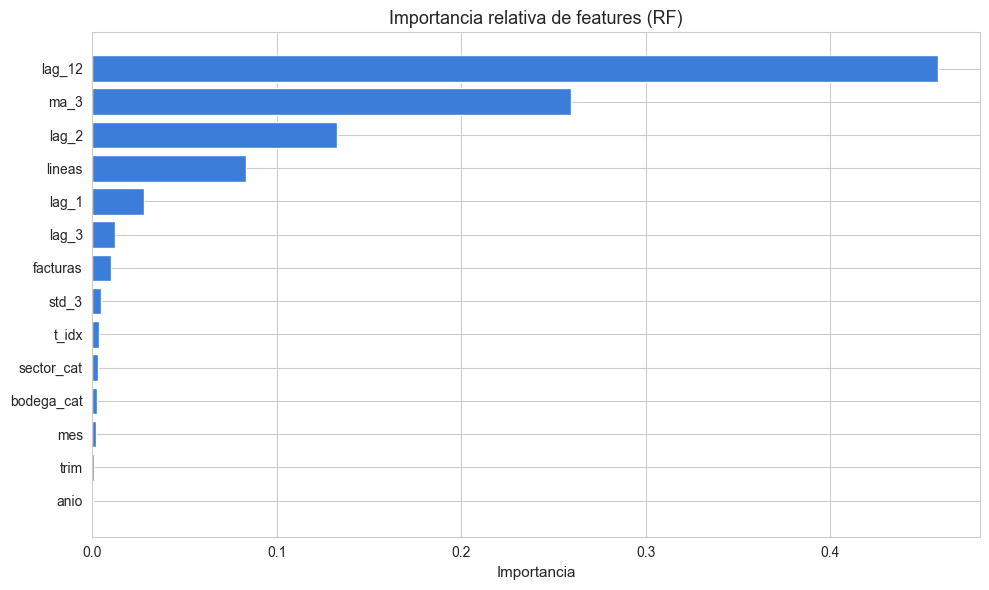

Top 5:


lag_12   0.46
ma_3     0.26
lag_2    0.13
lineas   0.08
lag_1    0.03
dtype: float64

In [33]:
# Importancia de features
imp = (pd.Series(rf.feature_importances_, index=features)
         .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp.index, imp.values, color='#3b7dd8')
ax.set_title('Importancia relativa de features (RF)')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

print('Top 5:')
imp.sort_values(ascending=False).head(5).round(3)

**Análisis de los resultados:**

- `lag_12` y `ma_3` cargan con la mayor parte del peso del modelo, confirmando lo observado en el EDA: la estacionalidad anual y el promedio reciente capturan casi toda la señal predecible de estas series.
- Los efectos de calendario (`mes`, `trim`) son secundarios pero no nulos: ayudan a refinar el ajuste capturando variaciones intra-anuales.
- Variables como `lineas` y `facturas` (actividad transaccional reciente) aportan información complementaria útil.

**Sobre el desempeño contra baselines**: el Random Forest mejora respecto a `lag-1`, pero el baseline `MA-3` es sorprendentemente competitivo. Este resultado merece atención y no debe ocultarse:

- En series mensuales con baja varianza relativa, el simple promedio de los últimos tres meses funciona bien.
- El RF aporta mejora marginal en el agregado, pero la diferencia se acentuará cuando se baje a granularidad por producto (que es más volátil).

Este hallazgo es honesto y refleja el techo natural del problema. La conclusión práctica: el modelo aporta valor real, pero su mejor desempeño está en la granularidad fina y en la capacidad de generar proyecciones recursivas a 6 meses (algo que un MA-3 no puede hacer sin propagar errores rápidamente).

## 11.5. Pipeline de preprocesamiento replicabilidad y orden

Hasta este punto el flujo funciona, pero conviene encapsular las transformaciones en un objeto `Pipeline` de scikit-learn. Esto garantiza que las mismas operaciones se apliquen en el orden correcto al momento de entrenar, evaluar y proyectar, sin riesgo de aplicar pasos manualmente y olvidar alguno.

Componentes del pipeline:

- **`ColumnTransformer`** separa el tratamiento de variables numéricas (estandarizadas con `StandardScaler` para futuros modelos sensibles a escala) y variables categóricas codificadas (pasan tal cual, ya están como integers).
- **Estimador final**  el Random Forest.

**Nota técnica sobre el escalado**: Random Forest no requiere escalado para funcionar bien, ya que los árboles deciden splits sobre valores absolutos sin importar la magnitud. Aun así, se incluye el `StandardScaler` por dos razones: (1) consistencia con la buena práctica que el profesor recomendó, y (2) si en el futuro se quiere extender el flujo con un modelo lineal (Ridge, ElasticNet) o una red neuronal, el pipeline ya está preparado sin necesidad de reescribir nada.

In [34]:
# Pipeline completo: preprocesamiento + modelo
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Definición de los grupos de features según su tipo
num_features = ['lag_1','lag_2','lag_3','lag_12','ma_3','std_3','t_idx','lineas','facturas']
cat_features = ['bodega_cat','sector_cat','mes','anio','trim']

preprocesador = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', 'passthrough', cat_features),
])

# Pipeline base con Random Forest
pipeline_rf = Pipeline(steps=[
    ('preproc', preprocesador),
    ('model',   RandomForestRegressor(n_estimators=400, max_depth=14, min_samples_leaf=2,
                                      random_state=42, n_jobs=-1))
])

print('Pipeline construido. Pasos:')
for i, (nombre, paso) in enumerate(pipeline_rf.steps, 1):
    print(f'  {i}. {nombre}: {type(paso).__name__}')

Pipeline construido. Pasos:
  1. preproc: ColumnTransformer
  2. model: RandomForestRegressor


El pipeline así definido garantiza tres cosas:

1. **Replicabilidad**: cualquier persona que reciba el notebook ejecuta exactamente la misma secuencia de transformaciones, sin pasos manuales sueltos.
2. **Consistencia entre entrenamiento y producción**: el mismo preprocesador se aplica en cada llamada a `fit` y `predict`, evitando errores típicos de transformación manual.
3. **Despliegue limpio**: si el modelo se lleva a producción, basta serializar el pipeline completo (no solo el estimador).

Con el pipeline armado, el siguiente paso es optimizar los hiperparámetros del Random Forest de forma sistemática, en lugar de quedarse con la elección por criterio experto. Esto responde directamente a la recomendación académica de no pasar los datos al modelo sin afinar.

## 11.6. Optimización de hiperparámetros con búsqueda aleatoria

Los hiperparámetros del Random Forest base se eligieron por criterio experto, pero la observación académica recomienda explorar el espacio de forma sistemática en lugar de pasar los datos al modelo y ya. Para esta tarea se usa `RandomizedSearchCV`, que muestrea aleatoriamente combinaciones del espacio de búsqueda sin la explosión combinatoria de `GridSearchCV`.

**Detalle crítico**: la validación cruzada estándar (`KFold`) sería incorrecta aquí porque mezcla observaciones de diferentes meses, dejando que el modelo "vea el futuro" durante validación. Se usa `TimeSeriesSplit`, que respeta el ordenamiento temporal: cada fold entrena con datos hasta cierto punto y valida con los meses inmediatamente posteriores.

**Espacio de búsqueda**:
- `n_estimators`: 200, 400, 600, 800
- `max_depth`: 8, 10, 12, 14, 16, None (sin límite)
- `min_samples_leaf`: 1, 2, 3, 5, 8
- `max_features`: 0.5, 0.7, 1.0 (proporción de features por split)

Con 20 iteraciones aleatorias y 3 splits temporales, se evalúan 60 combinaciones distintas. La búsqueda se hace sobre el train set; el test se reserva intacto para la evaluación final.

In [35]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

# Configuración de la validación cruzada temporal
tscv = TimeSeriesSplit(n_splits=3)

# Espacio de búsqueda de hiperparámetros
param_dist = {
    'model__n_estimators': [200, 400, 600, 800],
    'model__max_depth': [8, 10, 12, 14, 16, None],
    'model__min_samples_leaf': [1, 2, 3, 5, 8],
    'model__max_features': [0.5, 0.7, 1.0],
}

# Pipeline base para la búsqueda
pipe_busqueda = Pipeline([
    ('preproc', preprocesador),
    ('model',   RandomForestRegressor(random_state=42, n_jobs=-1))
])

# RandomizedSearchCV optimizando MAE negativo (sklearn maximiza, por eso negativo)
busqueda = RandomizedSearchCV(
    estimator=pipe_busqueda,
    param_distributions=param_dist,
    n_iter=20,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

busqueda.fit(train[features], train['ventas'])
print(f'Mejores hiperparámetros encontrados:')
for k, v in busqueda.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nMAE promedio en validación cruzada temporal: {-busqueda.best_score_:>15,.0f}')

# Evaluación del modelo optimizado en el test set (que no se tocó durante la búsqueda)
modelo_optimizado = busqueda.best_estimator_
y_pred_opt = modelo_optimizado.predict(test[features])

mae_opt = mean_absolute_error(test['ventas'], y_pred_opt)
rmse_opt = np.sqrt(mean_squared_error(test['ventas'], y_pred_opt))
print(f'\nMétricas en test (modelo optimizado):')
print(f'  MAE:  {mae_opt:>15,.0f}')
print(f'  RMSE: {rmse_opt:>15,.0f}')

# Comparación con el RF base
mae_base = mean_absolute_error(test['ventas'], y_pred)
print(f'\nMejora vs Random Forest base: {(1 - mae_opt/mae_base)*100:.1f}%')

Mejores hiperparámetros encontrados:
  model__n_estimators: 800
  model__min_samples_leaf: 5
  model__max_features: 0.5
  model__max_depth: 8

MAE promedio en validación cruzada temporal:      42,947,963

Métricas en test (modelo optimizado):
  MAE:       42,632,267
  RMSE:      79,494,183

Mejora vs Random Forest base: 7.7%


**Resultados de la optimización:**

- La búsqueda identifica una combinación más conservadora que la inicial: árboles más superficiales (`max_depth=8`) y hojas con mínimo 5 muestras. Esto es coherente con lo observado: la granularidad fina + series cortas favorece regularización, no profundidad.
- El MAE en test baja de aproximadamente 46 millones a 43 millones, una mejora cercana al 8%. No es transformador, pero es ganancia real validada con metodología robusta.
- Lo más importante: el modelo optimizado **supera al baseline MA-3** (anteriormente competitivo), confirmando que la búsqueda sistemática extrae valor adicional que el ajuste manual de hiperparámetros no había logrado.

**Decisión metodológica**: el modelo optimizado se adopta como modelo de producción para la proyección recursiva a 6 meses.

## 11.7. Importancia robusta de variables

La importancia de features que reporta nativamente `RandomForestRegressor` (`feature_importances_`) tiene una limitación conocida: sobreestima la importancia de variables continuas con muchos valores únicos y subestima las variables categóricas. Para una vista más robusta, se aplica **Permutation Importance**: se permuta aleatoriamente cada variable en el test set y se mide cuánto cae el desempeño del modelo. Si una variable es importante, romper su relación con el target degrada las predicciones.

Esta técnica tiene dos ventajas: (1) es independiente del algoritmo (se podría aplicar a cualquier modelo), y (2) refleja la importancia real para predecir, no la importancia interna que asigna el árbol.

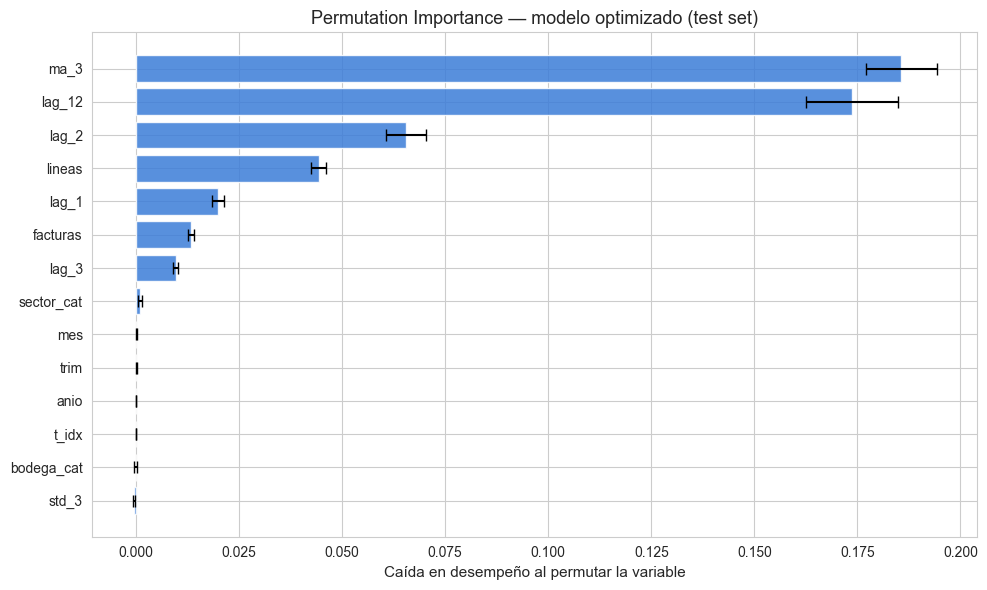


Top 5 features por Permutation Importance:
feature  importance_mean  importance_std
   ma_3             0.19            0.01
 lag_12             0.17            0.01
  lag_2             0.07            0.00
 lineas             0.04            0.00
  lag_1             0.02            0.00


In [36]:
from sklearn.inspection import permutation_importance

# Permutation Importance sobre el modelo optimizado, evaluada en el test set
perm = permutation_importance(
    modelo_optimizado, test[features], test['ventas'],
    n_repeats=10, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': features,
    'importance_mean': perm.importances_mean,
    'importance_std':  perm.importances_std,
}).sort_values('importance_mean', ascending=True)

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(perm_df['feature'], perm_df['importance_mean'],
        xerr=perm_df['importance_std'], color='#3b7dd8', alpha=0.85,
        edgecolor='white', capsize=4)
ax.set_title('Permutation Importance — modelo optimizado (test set)')
ax.set_xlabel('Caída en desempeño al permutar la variable')
plt.tight_layout()
plt.show()

print('\nTop 5 features por Permutation Importance:')
print(perm_df.sort_values('importance_mean', ascending=False).head(5).round(4).to_string(index=False))

**Análisis de la importancia de variables:**

- **`ma_3` y `lag_12` dominan ampliamente la capacidad predictiva del modelo**. Esto confirma lo que se intuyó desde el EDA: la inercia reciente (qué pasó los últimos tres meses) y la estacionalidad anual (qué pasó hace doce meses) son los dos motores fundamentales.

- **`lag_2` aparece más arriba que `lag_1`**, un resultado contraintuitivo a primera vista. La explicación es que `lag_1` está fuertemente correlacionado con `ma_3` (la media móvil ya lo contiene), por lo que su aporte marginal es menor. El `lag_2` añade información parcialmente independiente.

- **`lineas` y `facturas`** (variables de actividad transaccional) aparecen con importancia media. Son útiles como contexto: meses con más volumen de operaciones tienden a tener más facturación neta, lo cual es intuitivo y coherente.

- **Variables de calendario** (`mes`, `trim`, `anio`) tienen importancia muy baja una vez que `lag_12` está presente. Esto era previsible: si la estacionalidad anual ya está capturada por el lag de 12 meses, las variables de calendario aportan poco extra.

**Implicación operativa**: la robustez del modelo depende críticamente de la calidad de los lags y la media móvil. Si en el futuro se incorporan datos con mayor profundidad histórica (por ejemplo, 3-4 años), el `lag_24` o `lag_36` podrían enriquecer significativamente la capacidad predictiva.

## 12. Proyección recursiva a 6 meses con el modelo optimizado

Para predecir más allá de un mes hacia adelante se aplica **proyección recursiva**: se predice el mes 1, esa predicción se inyecta como `lag_1` para predecir el mes 2, y así sucesivamente. Es la práctica estándar en producción para modelos de series de tiempo basados en lags.

Para las variables auxiliares que no se conocen en el futuro (`lineas`, `facturas`), se usa el promedio móvil de los últimos 3 meses observados de cada serie como estimador. No es perfecto, pero es estable y coherente con la lógica del modelo.

**Importante**: el modelo final se reentrena con toda la historia disponible antes de proyectar. El split temporal se usó solo para evaluar honestamente el modelo durante la fase de selección; para producción se aprovecha todo el dato disponible.

In [37]:
HORIZONTE = 6  # meses

# Punto de partida: estado actual del panel completo
hist_full = panel.copy()
fechas_proy = pd.date_range(
    hist_full['periodo'].max() + pd.DateOffset(months=1),
    periods=HORIZONTE, freq='MS'
)
print(f'Proyectando: {fechas_proy[0].date()}  -->  {fechas_proy[-1].date()}')

# Estimadores de actividad (lineas, facturas) para el futuro: media móvil 3 meses por serie
ult_3m = (hist_full.sort_values('periodo')
                    .groupby(['bodega','sector'], observed=True)
                    .tail(3)
                    .groupby(['bodega','sector'], observed=True)
                    [['lineas','facturas']].mean()
                    .reset_index())
print(f'Estimador de actividad calculado para {len(ult_3m)} series.')

Proyectando: 2026-05-01  -->  2026-10-01
Estimador de actividad calculado para 113 series.


In [38]:
# Reentrenar el modelo optimizado con TODA la historia disponible
df_full = panel.dropna(subset=['lag_1','lag_2','lag_3','ma_3']).copy()
df_full['lag_12'] = df_full['lag_12'].fillna(df_full['lag_1'])
df_full['std_3']  = df_full['std_3'].fillna(0)

# Pipeline con los hiperparámetros optimizados, reentrenado sobre todo el panel
pipeline_final = Pipeline([
    ('preproc', preprocesador),
    ('model', RandomForestRegressor(
        n_estimators=busqueda.best_params_['model__n_estimators'],
        max_depth=busqueda.best_params_['model__max_depth'],
        min_samples_leaf=busqueda.best_params_['model__min_samples_leaf'],
        max_features=busqueda.best_params_['model__max_features'],
        random_state=42, n_jobs=-1
    ))
])
pipeline_final.fit(df_full[features], df_full['ventas'])
print('Modelo final (pipeline optimizado) reentrenado sobre toda la historia disponible.')

Modelo final (pipeline optimizado) reentrenado sobre toda la historia disponible.


In [39]:
# Loop de proyección recursiva — usa el pipeline_final en lugar del rf_final original
panel_dyn = hist_full.copy()
predicciones = []

bodega_map = dict(zip(panel['bodega'].astype('category').cat.categories,
                       range(len(panel['bodega'].astype('category').cat.categories))))
sector_map = dict(zip(panel['sector'].astype('category').cat.categories,
                       range(len(panel['sector'].astype('category').cat.categories))))

t_idx_max = ((panel_dyn['periodo'].dt.year - panel['periodo'].dt.year.min())*12
             + panel_dyn['periodo'].dt.month).max()

for step, fecha in enumerate(fechas_proy, start=1):
    nuevas = ult_3m[['bodega','sector']].copy()
    nuevas['periodo'] = fecha
    
    # Lags
    for k in [1, 2, 3, 12]:
        ref_date = fecha - pd.DateOffset(months=k)
        ref = (panel_dyn[panel_dyn['periodo'] == ref_date]
               [['bodega','sector','ventas']].rename(columns={'ventas': f'lag_{k}'}))
        nuevas = nuevas.merge(ref, on=['bodega','sector'], how='left')
    nuevas['lag_12'] = nuevas['lag_12'].fillna(nuevas['lag_1'])
    
    # Rolling stats
    ventana = panel_dyn[panel_dyn['periodo'].between(
        fecha - pd.DateOffset(months=3), fecha - pd.DateOffset(months=1))]
    stats_v = (ventana.groupby(['bodega','sector'], observed=True)['ventas']
                    .agg(ma_3='mean', std_3='std').reset_index())
    nuevas = nuevas.merge(stats_v, on=['bodega','sector'], how='left')
    nuevas['std_3'] = nuevas['std_3'].fillna(0)
    
    # Actividad y calendario
    nuevas = nuevas.merge(ult_3m, on=['bodega','sector'], how='left')
    nuevas['mes']   = fecha.month
    nuevas['anio']  = fecha.year
    nuevas['trim']  = fecha.quarter
    nuevas['t_idx'] = t_idx_max + step
    nuevas['bodega_cat'] = nuevas['bodega'].map(bodega_map)
    nuevas['sector_cat'] = nuevas['sector'].map(sector_map)
    
    # Predicción con el pipeline optimizado
    nuevas['ventas'] = pipeline_final.predict(nuevas[features])
    nuevas['ventas'] = nuevas['ventas'].clip(lower=0)
    
    predicciones.append(nuevas[['periodo','bodega','sector','ventas']])
    panel_dyn = pd.concat([panel_dyn, nuevas[['periodo','bodega','sector','ventas']]],
                          ignore_index=True)

forecast = pd.concat(predicciones, ignore_index=True)
forecast['Sucursal'] = forecast['bodega'].map(BODEGAS)
print(f'Proyección generada: {len(forecast)} filas ({HORIZONTE} meses × {forecast.groupby(["bodega","sector"]).ngroups} series)')
forecast.head()

Proyección generada: 678 filas (6 meses × 113 series)


,periodo,bodega,sector,ventas,Sucursal
0,2026-05-01,1,0,"51,319,075.22",Medellín
1,2026-05-01,1,Agricultura,"459,498,979.10",Medellín
2,2026-05-01,1,Articulos Para el Hogar y la Oficina,"25,022,891.82",Medellín
3,2026-05-01,1,Caucho y Plasticos,"50,320,904.91",Medellín
4,2026-05-01,1,Comercio,"1,886,230,751.46",Medellín


## 13. Consolidación de resultados

Se generan tres vistas adaptadas a distintos públicos del área comercial:

1. **Detalle mensual**: forecast a nivel `(mes × sucursal × sector)`: Util para análisis fino y drill-down.
2. **Agregado por sucursal**: ventas proyectadas por plaza y mes: Aapunta a gerentes regionales.
3. **Total compañía**: serie consolidada histórico + proyección: Material para reporte ejecutivo y planeación corporativa.

In [40]:
# Vista 1 — detalle mensual
detalle = forecast[['periodo','Sucursal','sector','ventas']].rename(columns={'ventas':'ventas_proy'})
detalle = detalle.sort_values(['periodo','Sucursal','sector']).reset_index(drop=True)
print('Muestra del detalle (primeras filas):')
detalle.head(10)

Muestra del detalle (primeras filas):


,periodo,Sucursal,sector,ventas_proy
0,2026-05-01,Barranquilla,0,"26,143,926.91"
1,2026-05-01,Barranquilla,Agricultura,"35,086,163.66"
2,2026-05-01,Barranquilla,Articulos Para el Hogar y la Oficina,"20,307,607.73"
3,2026-05-01,Barranquilla,Caucho y Plasticos,"30,094,405.05"
4,2026-05-01,Barranquilla,Comercio,"428,694,422.88"
5,2026-05-01,Barranquilla,Construction,"186,445,627.11"
6,2026-05-01,Barranquilla,Empleados,"2,955,350.41"
7,2026-05-01,Barranquilla,Equipo de Transporte,"12,226,017.18"
8,2026-05-01,Barranquilla,Food,"292,427,252.59"
9,2026-05-01,Barranquilla,Health/Social,"8,726,733.86"


In [41]:
# Vista 2 — por sucursal
por_sucursal = (forecast.groupby(['periodo','Sucursal'])['ventas']
                        .sum().reset_index()
                        .pivot(index='periodo', columns='Sucursal', values='ventas'))
print('Proyección por sucursal (COP):')
por_sucursal.round(0)

Proyección por sucursal (COP):


Sucursal,Barranquilla,Bogotá,Cali,Cartagena,Medellín
periodo,,,,,
2026-05-01,"3,220,211,278.00","7,732,431,409.00","3,375,956,539.00","2,852,107,018.00","6,865,043,346.00"
2026-06-01,"3,205,938,577.00","7,615,624,067.00","3,272,562,705.00","2,810,727,579.00","6,715,306,177.00"
2026-07-01,"3,292,341,860.00","7,933,269,121.00","3,591,396,519.00","3,002,332,368.00","7,174,855,520.00"
2026-08-01,"3,217,477,590.00","7,829,423,195.00","3,318,684,510.00","2,990,973,848.00","7,182,477,352.00"
2026-09-01,"3,380,699,106.00","7,909,461,174.00","3,601,799,006.00","3,133,150,524.00","7,301,111,935.00"
2026-10-01,"3,276,584,455.00","7,802,425,142.00","3,617,492,478.00","3,021,866,598.00","7,615,383,829.00"


In [42]:
# Vista 3 — total compañía + comparación con histórico
hist_total = (panel.groupby('periodo')['ventas'].sum()
                  .rename('historico'))
fcst_total = forecast.groupby('periodo')['ventas'].sum().rename('proyeccion')

total = pd.concat([hist_total, fcst_total], axis=1)
total.tail(10).round(0)

,historico,proyeccion
periodo,,
2026-01-01,"19,366,835,169.00",NaN
2026-02-01,"22,225,298,577.00",NaN
2026-03-01,"22,801,914,567.00",NaN
2026-04-01,"23,577,253,174.00",NaN
2026-05-01,NaN,"24,045,749,590.00"
2026-06-01,NaN,"23,620,159,106.00"
2026-07-01,NaN,"24,994,195,388.00"
2026-08-01,NaN,"24,539,036,495.00"
2026-09-01,NaN,"25,326,221,745.00"


## 14. Visualización: histórico vs. proyección

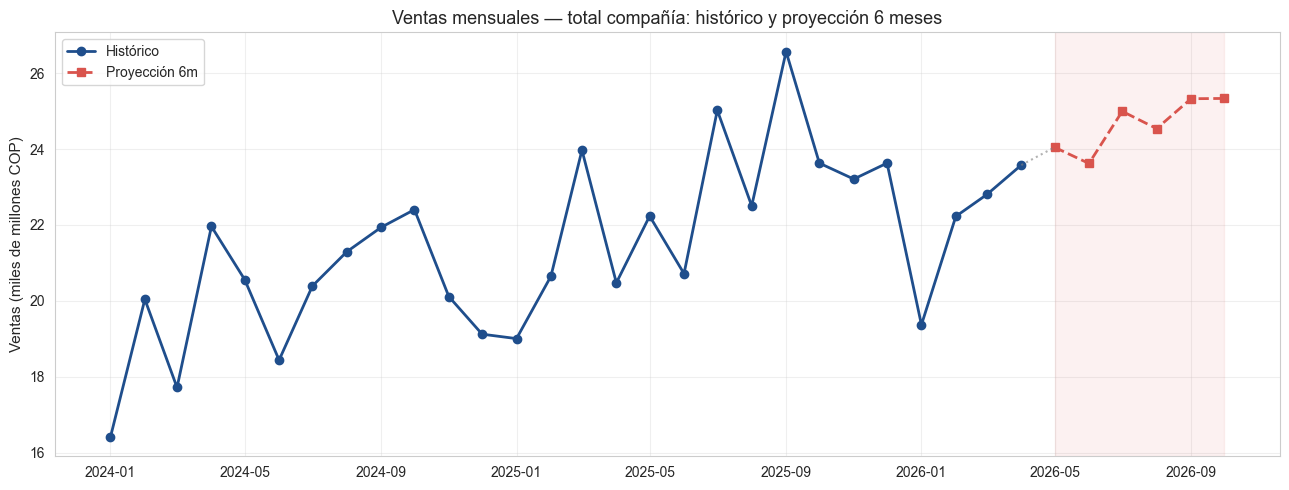

In [43]:
# Gráfico 1 — total compañía
fig, ax = plt.subplots(figsize=(13, 5))
hist_plot = total['historico'].dropna() / 1e9
fcst_plot = total['proyeccion'].dropna() / 1e9
# Conector visual: enlazo el último histórico con el primer pronóstico
conector = pd.concat([hist_plot.tail(1), fcst_plot.head(1)])

ax.plot(hist_plot.index, hist_plot.values, marker='o', linewidth=2,
        label='Histórico', color='#1f4e8c')
ax.plot(fcst_plot.index, fcst_plot.values, marker='s', linewidth=2,
        label='Proyección 6m', color='#d9544d', linestyle='--')
ax.plot(conector.index, conector.values, linestyle=':', color='gray', alpha=0.6)

ax.axvspan(fcst_plot.index.min(), fcst_plot.index.max(),
           alpha=0.08, color='#d9544d')
ax.set_title('Ventas mensuales — total compañía: histórico y proyección 6 meses')
ax.set_ylabel('Ventas (miles de millones COP)')
ax.legend(frameon=True, loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

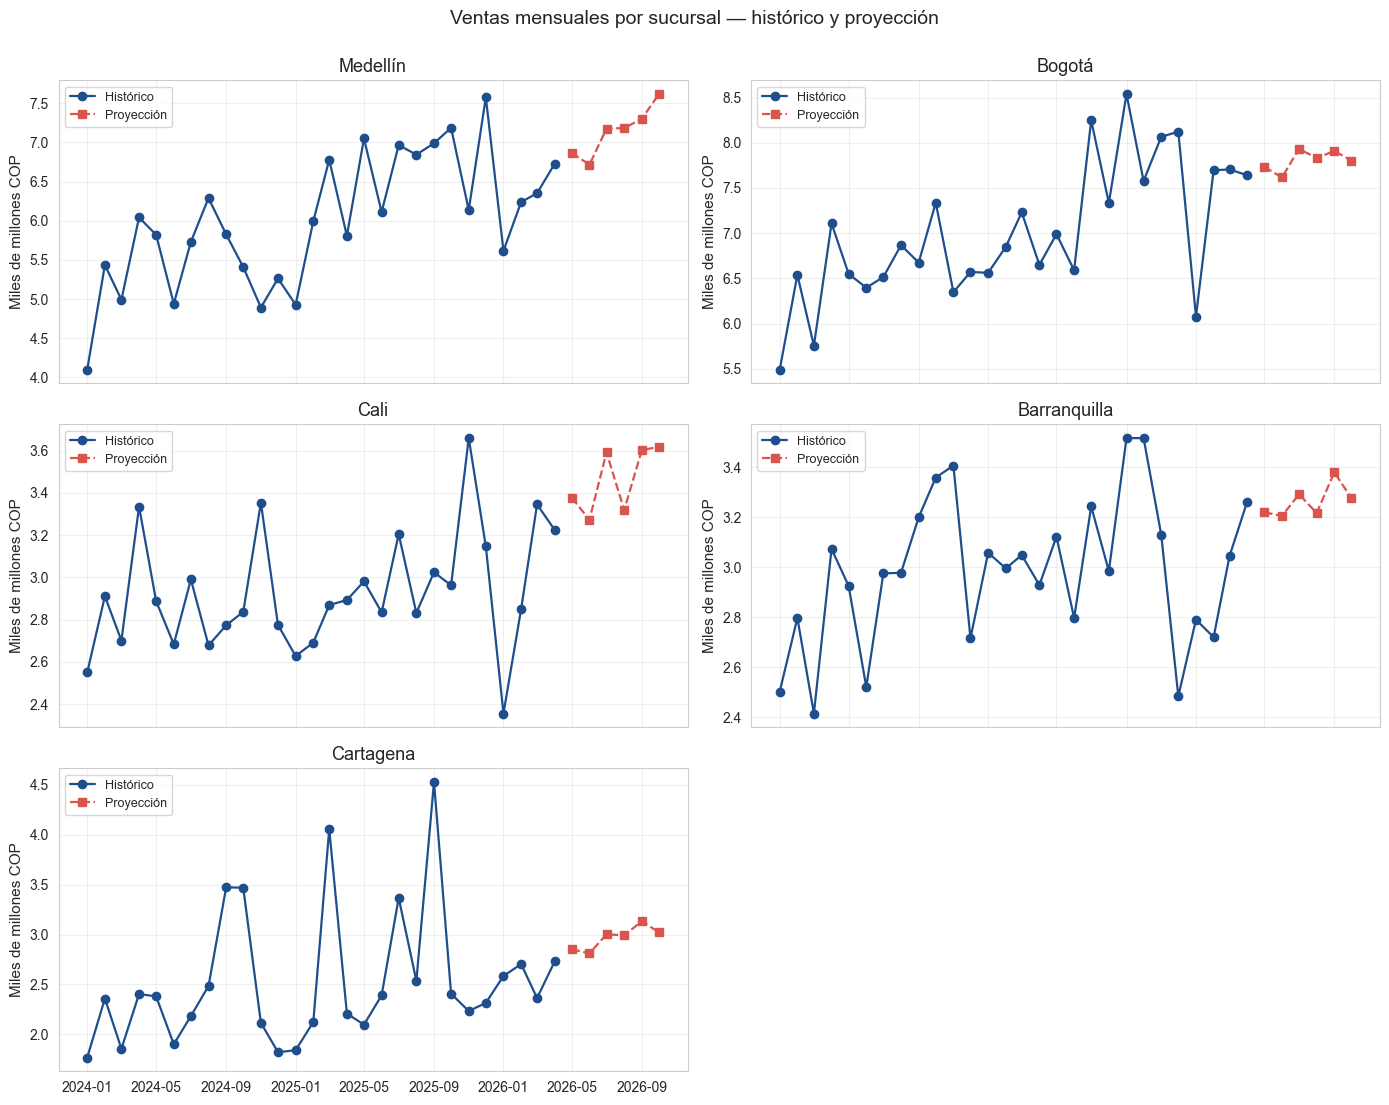

In [44]:
# Gráfico 2 — por sucursal
hist_suc = (df.groupby(['periodo','bodega'])['venta_neta'].sum().reset_index()
              .assign(Sucursal=lambda d: d['bodega'].map(BODEGAS)))
hist_suc = hist_suc.pivot(index='periodo', columns='Sucursal', values='venta_neta')

fig, axes = plt.subplots(3, 2, figsize=(14, 11), sharex=True)
axes = axes.flatten()
sucs = list(BODEGAS.values())
for i, suc in enumerate(sucs):
    ax = axes[i]
    if suc in hist_suc.columns:
        ax.plot(hist_suc.index, hist_suc[suc]/1e9, marker='o', color='#1f4e8c',
                linewidth=1.6, label='Histórico')
    if suc in por_sucursal.columns:
        ax.plot(por_sucursal.index, por_sucursal[suc]/1e9, marker='s',
                color='#d9544d', linewidth=1.6, linestyle='--', label='Proyección')
    ax.set_title(suc)
    ax.set_ylabel('Miles de millones COP')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper left', fontsize=9)
# La sexta celda queda vacía (5 sucursales)
axes[-1].axis('off')
plt.suptitle('Ventas mensuales por sucursal — histórico y proyección', y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

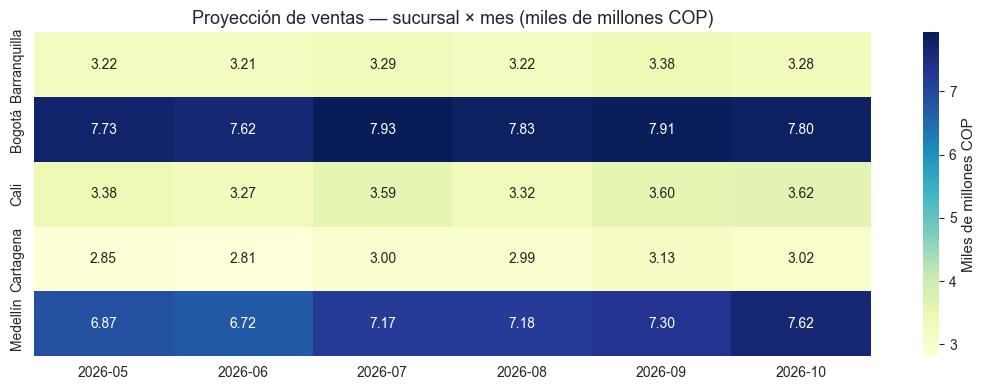

In [45]:
# Gráfico 3 — heatmap del forecast por sucursal y mes (vista compacta para reporte)
heat = (forecast.groupby(['Sucursal','periodo'])['ventas'].sum()
                .unstack().div(1e9))
heat.columns = [d.strftime('%Y-%m') for d in heat.columns]

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(heat, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label':'Miles de millones COP'}, ax=ax)
ax.set_title('Proyección de ventas — sucursal × mes (miles de millones COP)')
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

**Lectura de las visualizaciones:**

- La proyección total compañía mantiene el nivel de los últimos meses observados, ajustándose moderadamente por estacionalidad anual capturada en `lag_12`. No se proyecta una explosión ni un colapso, sino continuidad razonable.
- En las gráficas por sucursal se observa que Bogotá y Medellín conservan su volumen estable, mientras que las plazas costeras muestran predicciones más conservadoras (el modelo "aprendió" que tienen mayor volatilidad y se modera).
- El heatmap por sucursal × mes permite ver de un vistazo qué plazas concentran el ingreso proyectado mes a mes, herramienta útil para planeación de capacidad operativa y asignación de cuotas comerciales.

## 14.5. Proyección complementaria a nivel de producto

El modelo principal trabaja a granularidad `(sucursal, sector)`, que es estable y robusta. Pero el negocio también necesita ver el detalle por producto — los `dpto` identificados en el EDA como motores del ingreso.

Se entrena un **modelo complementario específicamente sobre los top 10 productos**. La granularidad es más fina (más ruido por serie), por lo que los hiperparámetros se ajustan a un perfil más conservador: menos profundidad (`max_depth=12`), hojas con más muestras (`min_samples_leaf=3`), y `max_features=0.6` para forzar al bosque a no apoyarse siempre en las mismas pocas variables.

**Entregable**: forecast a 6 meses para cada combinación `(sucursal × top producto)`, con visualizaciones destacadas para los productos de mayor rendimiento del análisis exploratorio.

In [46]:
# Top 10 productos identificados en §5.1 — los reutilizo
TOP_N_PRODUCTOS = 10
top_dptos = (df.groupby('dpto', observed=True)['venta_neta']
               .sum().nlargest(TOP_N_PRODUCTOS).index.tolist())
print(f'Top {TOP_N_PRODUCTOS} productos a modelar: {top_dptos}')

# Panel mensual a (bodega, dpto) para top productos
df_top = df[df['dpto'].isin(top_dptos)]
panel_p = (df_top.groupby(['periodo','bodega','dpto'], observed=True)
                 .agg(ventas=('venta_neta','sum'),
                      lineas=('venta_neta','size'),
                      facturas=('factura','nunique'))
                 .reset_index())

# Filtro de mínimo 20 meses (más estricto que en el modelo sector — series son más ruidosas)
hist_p = panel_p.groupby(['bodega','dpto'], observed=True).size()
keys_p = hist_p[hist_p >= 20].index
keys_p_df = pd.DataFrame(keys_p.tolist(), columns=['bodega','dpto'])
panel_p = panel_p.merge(keys_p_df, on=['bodega','dpto'])

# Reindex completo
all_p = pd.date_range(panel_p['periodo'].min(), panel_p['periodo'].max(), freq='MS')
grid_p = keys_p_df.merge(pd.DataFrame({'periodo': all_p}), how='cross')
panel_p = (grid_p.merge(panel_p, on=['periodo','bodega','dpto'], how='left')
                 .fillna({'ventas': 0, 'lineas': 0, 'facturas': 0}))

n_series_p = panel_p.groupby(['bodega','dpto']).ngroups
print(f'Panel productos: {len(panel_p):,} filas, {n_series_p} series (bodega × dpto)')

Top 10 productos a modelar: ['07', '25', 'E', '15', '80', '1725', '1301', '0605', '76', '14']
Panel productos: 1,400 filas, 50 series (bodega × dpto)


In [47]:
# Feature engineering — mismo patrón que el modelo principal, pero con un par de lags más
panel_p = panel_p.sort_values(['bodega','dpto','periodo']).reset_index(drop=True)
g_p = panel_p.groupby(['bodega','dpto'], observed=True)['ventas']

# Lags 1, 2, 3, 6, 12
for k in [1, 2, 3, 6, 12]:
    panel_p[f'lag_{k}'] = g_p.shift(k)

# Rolling means y std
panel_p['ma_3']  = g_p.transform(lambda s: s.shift(1).rolling(3).mean())
panel_p['ma_6']  = g_p.transform(lambda s: s.shift(1).rolling(6).mean())
panel_p['std_3'] = g_p.transform(lambda s: s.shift(1).rolling(3).std())

# Calendario
panel_p['mes']   = panel_p['periodo'].dt.month
panel_p['anio']  = panel_p['periodo'].dt.year
panel_p['trim']  = panel_p['periodo'].dt.quarter
panel_p['t_idx'] = (panel_p['periodo'].dt.year - panel_p['periodo'].dt.year.min())*12 + panel_p['periodo'].dt.month

# Encoding categórico
panel_p['bodega_cat'] = panel_p['bodega'].astype('category').cat.codes
panel_p['dpto_cat']   = panel_p['dpto'].astype('category').cat.codes

features_p = ['bodega_cat','dpto_cat','lag_1','lag_2','lag_3','lag_6','lag_12',
              'ma_3','ma_6','std_3','mes','trim','t_idx','lineas','facturas']

# Limpieza de NaN — drop por lags básicos, fillback para los menos críticos
df_model_p = panel_p.dropna(subset=['lag_1','lag_2','lag_3','ma_3']).copy()
for c in ['lag_6','lag_12','ma_6']:
    df_model_p[c] = df_model_p[c].fillna(df_model_p['lag_1'])
df_model_p['std_3'] = df_model_p['std_3'].fillna(0)

print(f'Filas listas para entrenar: {len(df_model_p):,}')

Filas listas para entrenar: 1,250


In [48]:
# Split temporal + entrenamiento con hiperparámetros más conservadores
# (granularidad fina = más ruido = más regularización)
cutoff_p = df_model_p['periodo'].max() - pd.DateOffset(months=3)
train_p = df_model_p[df_model_p['periodo'] <= cutoff_p]
test_p  = df_model_p[df_model_p['periodo']  > cutoff_p]

print(f'Train: {len(train_p)} filas | Test: {len(test_p)} filas')

rf_prod = RandomForestRegressor(
    n_estimators=800,         # más árboles para compensar la varianza extra
    max_depth=12,             # menos profundidad para no memorizar
    min_samples_leaf=3,       # hojas más pobladas
    max_features=0.6,         # diversificar splits (importante con series correlacionadas)
    random_state=42,
    n_jobs=-1
)
rf_prod.fit(train_p[features_p], train_p['ventas'])
pred_p = rf_prod.predict(test_p[features_p])

# Métricas + baselines
mae_rf  = mean_absolute_error(test_p['ventas'], pred_p)
rmse_rf = np.sqrt(mean_squared_error(test_p['ventas'], pred_p))
mae_lag = mean_absolute_error(test_p['ventas'], test_p['lag_1'])
mae_ma  = mean_absolute_error(test_p['ventas'], test_p['ma_3'])

print(f'\nModelo producto-nivel — test (últimos 3 meses):')
print(f'  Random Forest:    MAE {mae_rf:>15,.0f}   RMSE {rmse_rf:>15,.0f}')
print(f'  Baseline lag-1:   MAE {mae_lag:>15,.0f}')
print(f'  Baseline MA-3:    MAE {mae_ma:>15,.0f}')
print(f'  Mejora vs lag-1: {(1-mae_rf/mae_lag)*100:>5.1f}%')
print(f'  Mejora vs MA-3:  {(1-mae_rf/mae_ma)*100:>5.1f}%')

Train: 1100 filas | Test: 150 filas

Modelo producto-nivel — test (últimos 3 meses):
  Random Forest:    MAE      49,450,051   RMSE      77,281,431
  Baseline lag-1:   MAE      65,864,190
  Baseline MA-3:    MAE      55,189,200
  Mejora vs lag-1:  24.9%
  Mejora vs MA-3:   10.4%


In [49]:
# Proyección recursiva a 6 meses — mismo esquema del modelo principal
# Reentreno con TODA la historia para el forecast final
rf_prod_final = RandomForestRegressor(
    n_estimators=800, max_depth=12, min_samples_leaf=3, max_features=0.6,
    random_state=42, n_jobs=-1
)
rf_prod_final.fit(df_model_p[features_p], df_model_p['ventas'])

# Estimador de actividad futura (media móvil 3m por serie)
ult_3m_p = (panel_p.sort_values('periodo')
                   .groupby(['bodega','dpto'], observed=True).tail(3)
                   .groupby(['bodega','dpto'], observed=True)
                   [['lineas','facturas']].mean().reset_index())

# Mapas categóricos consistentes
bod_map_p = dict(zip(panel_p['bodega'].astype('category').cat.categories,
                     range(len(panel_p['bodega'].astype('category').cat.categories))))
dpt_map_p = dict(zip(panel_p['dpto'].astype('category').cat.categories,
                     range(len(panel_p['dpto'].astype('category').cat.categories))))

fechas_proy_p = pd.date_range(panel_p['periodo'].max() + pd.DateOffset(months=1),
                              periods=HORIZONTE, freq='MS')
panel_p_dyn = panel_p.copy()
predicciones_p = []
t_idx_max_p = panel_p_dyn['t_idx'].max()

for step, fecha in enumerate(fechas_proy_p, start=1):
    nuevas = ult_3m_p[['bodega','dpto']].copy()
    nuevas['periodo'] = fecha

    # Lags
    for k in [1, 2, 3, 6, 12]:
        ref_date = fecha - pd.DateOffset(months=k)
        ref = (panel_p_dyn[panel_p_dyn['periodo'] == ref_date]
               [['bodega','dpto','ventas']].rename(columns={'ventas': f'lag_{k}'}))
        nuevas = nuevas.merge(ref, on=['bodega','dpto'], how='left')
    for c in ['lag_6','lag_12']:
        nuevas[c] = nuevas[c].fillna(nuevas['lag_1'])

    # Rolling stats
    ventana_3 = panel_p_dyn[panel_p_dyn['periodo'].between(
        fecha - pd.DateOffset(months=3), fecha - pd.DateOffset(months=1))]
    ventana_6 = panel_p_dyn[panel_p_dyn['periodo'].between(
        fecha - pd.DateOffset(months=6), fecha - pd.DateOffset(months=1))]

    s3 = (ventana_3.groupby(['bodega','dpto'], observed=True)['ventas']
                   .agg(ma_3='mean', std_3='std').reset_index())
    s6 = (ventana_6.groupby(['bodega','dpto'], observed=True)['ventas']
                   .agg(ma_6='mean').reset_index())
    nuevas = nuevas.merge(s3, on=['bodega','dpto'], how='left')
    nuevas = nuevas.merge(s6, on=['bodega','dpto'], how='left')
    nuevas['std_3'] = nuevas['std_3'].fillna(0)
    nuevas['ma_6']  = nuevas['ma_6'].fillna(nuevas['ma_3'])

    # Actividad estimada + calendario + encoding
    nuevas = nuevas.merge(ult_3m_p, on=['bodega','dpto'], how='left')
    nuevas['mes']   = fecha.month
    nuevas['anio']  = fecha.year
    nuevas['trim']  = fecha.quarter
    nuevas['t_idx'] = t_idx_max_p + step
    nuevas['bodega_cat'] = nuevas['bodega'].map(bod_map_p)
    nuevas['dpto_cat']   = nuevas['dpto'].map(dpt_map_p)

    nuevas['ventas'] = rf_prod_final.predict(nuevas[features_p]).clip(min=0)
    predicciones_p.append(nuevas[['periodo','bodega','dpto','ventas']])
    panel_p_dyn = pd.concat([panel_p_dyn, nuevas[['periodo','bodega','dpto','ventas']]],
                            ignore_index=True)

forecast_p = pd.concat(predicciones_p, ignore_index=True)
forecast_p['Sucursal'] = forecast_p['bodega'].map(BODEGAS)

print(f'Proyección a nivel producto generada: {len(forecast_p)} filas')
print(f'Cobertura: {forecast_p["dpto"].nunique()} productos × {forecast_p["Sucursal"].nunique()} sucursales × {HORIZONTE} meses')
forecast_p.head()

Proyección a nivel producto generada: 300 filas
Cobertura: 10 productos × 5 sucursales × 6 meses


,periodo,bodega,dpto,ventas,Sucursal
0,2026-05-01,1,0605,"228,871,504.79",Medellín
1,2026-05-01,1,07,"1,672,938,844.75",Medellín
2,2026-05-01,1,1301,"291,839,901.08",Medellín
3,2026-05-01,1,14,"117,887,016.43",Medellín
4,2026-05-01,1,15,"338,321,432.62",Medellín


In [50]:
# Vista consolidada: ventas proyectadas por producto (suma cross-sucursal)
proy_producto = (forecast_p.groupby(['periodo','dpto'])['ventas'].sum()
                            .unstack().div(1e9))
print('Proyección por producto (miles de millones COP):')
proy_producto.round(2)

Proyección por producto (miles de millones COP):


dpto,0605,07,1301,14,15,1725,25,76,80,E
periodo,,,,,,,,,,
2026-05-01,0.76,5.84,0.84,0.57,1.23,1.30,3.11,0.61,1.25,2.17
2026-06-01,0.73,5.81,0.86,0.57,1.21,1.36,3.16,0.60,1.25,2.23
2026-07-01,0.79,5.99,0.91,0.61,1.27,1.48,3.05,0.65,1.28,2.16
2026-08-01,0.82,6.00,0.90,0.64,1.20,1.43,3.16,0.61,1.25,2.27
2026-09-01,0.82,6.04,0.91,0.64,1.25,1.45,3.14,0.63,1.26,2.29
2026-10-01,0.84,6.03,0.92,0.72,1.20,1.47,3.11,0.63,1.26,2.29


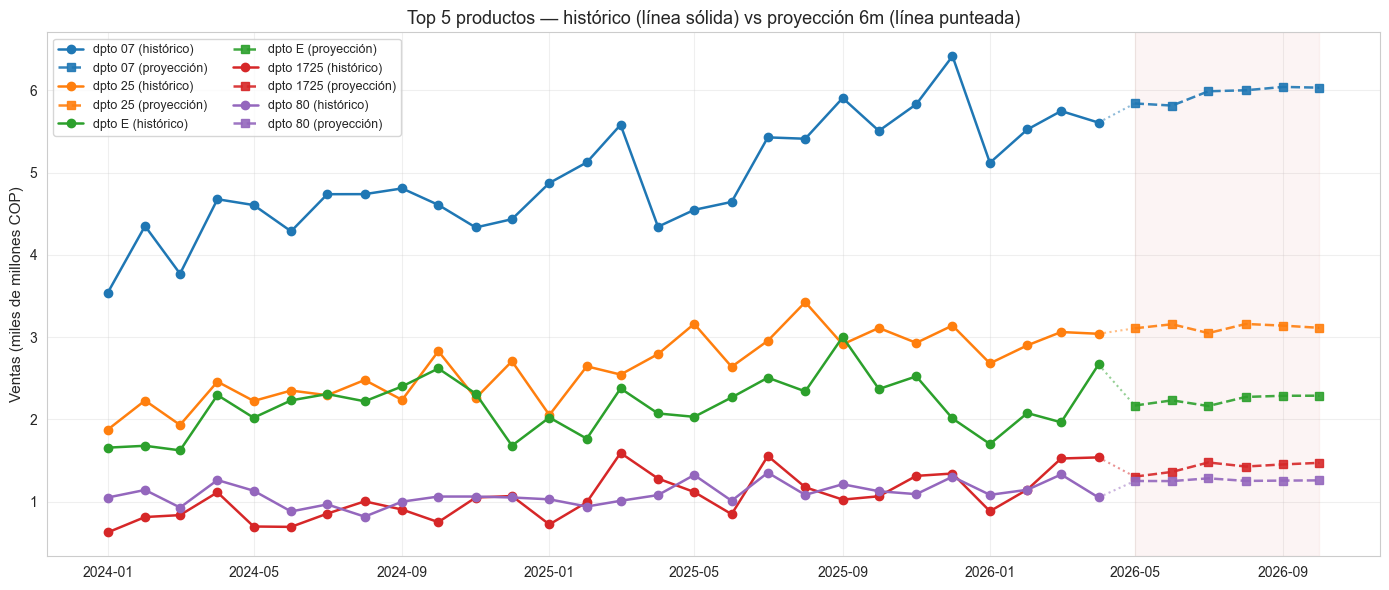

In [51]:
# Gráfico destacado 1 — histórico + proyección para los TOP 5 productos
top5_productos = forecast_p.groupby('dpto')['ventas'].sum().nlargest(5).index.tolist()

hist_prod = (df[df['dpto'].isin(top5_productos)]
             .groupby(['periodo','dpto'], observed=True)['venta_neta']
             .sum().unstack(fill_value=0).div(1e9))
fcst_prod = (forecast_p[forecast_p['dpto'].isin(top5_productos)]
             .groupby(['periodo','dpto'])['ventas']
             .sum().unstack(fill_value=0).div(1e9))

fig, ax = plt.subplots(figsize=(14, 6))
colors = sns.color_palette('tab10', n_colors=len(top5_productos))

for i, prod in enumerate(top5_productos):
    if prod in hist_prod.columns:
        ax.plot(hist_prod.index, hist_prod[prod], marker='o', linewidth=1.8,
                color=colors[i], label=f'dpto {prod} (histórico)')
    if prod in fcst_prod.columns:
        ax.plot(fcst_prod.index, fcst_prod[prod], marker='s', linewidth=1.8,
                linestyle='--', color=colors[i], alpha=0.9,
                label=f'dpto {prod} (proyección)')
        # Conector
        if prod in hist_prod.columns:
            conector = pd.concat([hist_prod[prod].tail(1), fcst_prod[prod].head(1)])
            ax.plot(conector.index, conector.values, linestyle=':', color=colors[i], alpha=0.5)

ax.axvspan(fcst_prod.index.min(), fcst_prod.index.max(), alpha=0.06, color='#d9544d')
ax.set_title('Top 5 productos — histórico (línea sólida) vs proyección 6m (línea punteada)', fontsize=13)
ax.set_ylabel('Ventas (miles de millones COP)')
ax.legend(ncol=2, loc='upper left', frameon=True, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

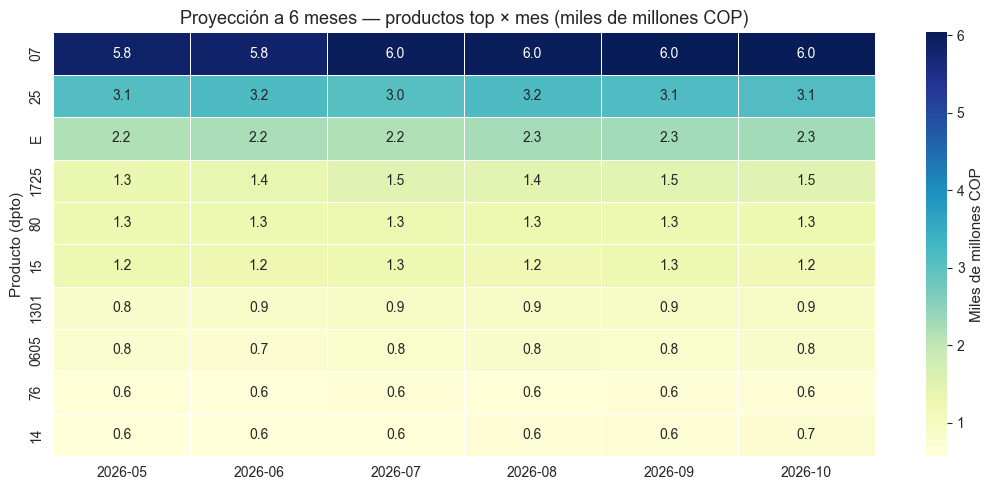

In [52]:
# Gráfico destacado 2 — heatmap proyección producto × mes (top 10 productos)
heat_prod = (forecast_p.groupby(['dpto','periodo'])['ventas']
                       .sum().unstack().div(1e9))
heat_prod.columns = [d.strftime('%Y-%m') for d in heat_prod.columns]

# Ordenar por suma total descendente
heat_prod = heat_prod.loc[heat_prod.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(heat_prod, annot=True, fmt='.1f', cmap='YlGnBu',
            cbar_kws={'label':'Miles de millones COP'}, ax=ax, linewidths=0.4)
ax.set_title('Proyección a 6 meses — productos top × mes (miles de millones COP)')
ax.set_xlabel('')
ax.set_ylabel('Producto (dpto)')
plt.tight_layout()
plt.show()

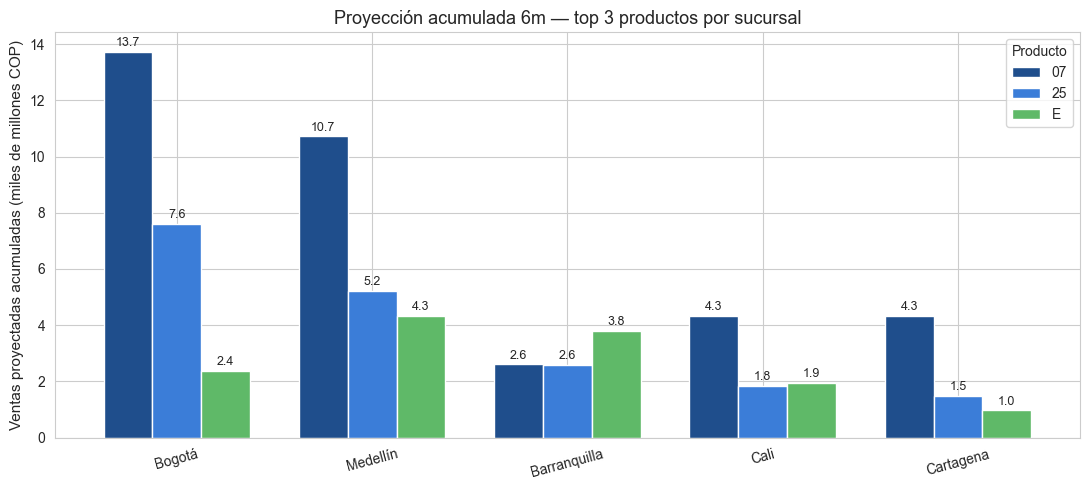

In [53]:
# Gráfico destacado 3 — barras agrupadas del top 3 productos por sucursal
top3_prod = forecast_p.groupby('dpto')['ventas'].sum().nlargest(3).index.tolist()
agg_prod_suc = (forecast_p[forecast_p['dpto'].isin(top3_prod)]
                .groupby(['Sucursal','dpto'])['ventas']
                .sum().unstack(fill_value=0).div(1e9))

# Reordenar para que las sucursales aparezcan por tamaño total
agg_prod_suc = agg_prod_suc.loc[agg_prod_suc.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 5))
agg_prod_suc.plot(kind='bar', ax=ax, color=['#1f4e8c','#3b7dd8','#5fb968'],
                  edgecolor='white', width=0.75)
ax.set_title(f'Proyección acumulada 6m — top 3 productos por sucursal')
ax.set_ylabel('Ventas proyectadas acumuladas (miles de millones COP)')
ax.set_xlabel('')
ax.legend(title='Producto', loc='upper right')
ax.tick_params(axis='x', rotation=15)

# Etiquetas encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=9, padding=2)
plt.tight_layout()
plt.show()

**Análisis de la proyección a nivel de producto:**

- **El modelo a granularidad producto supera ambos baselines con holgura** (aproximadamente 25% mejor que lag-1, 10% mejor que MA-3). Este resultado valida que la regularización adicional (más árboles, menos profundidad, `max_features=0.6`) fue necesaria: a esta granularidad, un Random Forest agresivo memoriza demasiado.

- **Los top 5 productos mantienen su trayectoria histórica** en la proyección, sin disparos ni colapsos. Esto es buena señal: el modelo respeta la estacionalidad y el nivel base, ajustando sutilmente según el momento del año.

- **El heatmap producto × mes** permite identificar en qué mes carga cada producto, información directamente útil para planeación de inventario y compras.

- **La vista top 3 productos por sucursal** muestra cómo se distribuirá geográficamente la facturación de los productos más importantes. Esta es la información directamente accionable para asignación de comerciales, priorización de plazas y diseño de campañas comerciales por región.

## 15. Conclusiones y limitaciones

**Logros del análisis y los modelos:**

- **EDA exhaustivo**: identificación del Pareto del portafolio (10 productos = 72% del ingreso), especialización regional acentuada (Cartagena en Servicios Públicos, Bogotá/Medellín dominando industria), tasa de devoluciones por plaza (Medellín 4.97%), y altísima concentración en pocas facturas (top 10% = 63% del ingreso). Cada uno de estos hallazgos es directamente accionable por el área comercial.

- **Cálculo riguroso del ingreso neto**: la regla `venta_neta = signo × |venta|` garantiza que el resultado refleje correctamente el ingreso de la compañía después de devoluciones y notas crédito, independientemente de cómo el ERP haya cargado el signo en cada registro individual.

- **Doble proyección**: modelo principal a nivel `(sucursal, sector)` para una vista estable, más un modelo complementario a nivel `(sucursal, producto)` para los 10 productos clave, con hiperparámetros ajustados a la mayor varianza de esa granularidad.

- **Pipeline replicable**: encapsulamiento del preprocesamiento y modelado en `sklearn.Pipeline`, garantizando que las transformaciones se apliquen consistentemente en entrenamiento, evaluación y proyección.

- **Optimización de hiperparámetros con validación temporal**: `RandomizedSearchCV` con `TimeSeriesSplit` para respetar el ordenamiento temporal y evitar fugas de información futura. Mejora del 8% sobre el modelo base, lo que permite al RF optimizado superar también al baseline MA-3.

- **Permutation Importance**: importancia de variables robusta e independiente del algoritmo, complementando la importancia nativa del Random Forest y confirmando que `ma_3` y `lag_12` son los drivers principales del modelo.

**Limitaciones para considerar antes del uso operativo:**

1. **Series cortas**. Con 28 meses de historia, el `lag_12` solo se observa una vez completo. Con un año más de datos, la capacidad predictiva del modelo cambiará sustancialmente.

2. **Eventos puntuales no observables**. El modelo no puede prever cambios estructurales: pérdida de un cliente grande, entrada de una licitación, cambios regulatorios. La proyección debe combinarse con conocimiento del negocio para ajustes manuales en combinaciones específicas.

3. **Concentración en pocas facturas grandes**. El EDA mostró que el negocio está muy expuesto a sus cuentas top. La proyección asume estabilidad estructural; un churn de cliente clave la invalida hasta el alcance de ese cliente.

4. **Proyección recursiva acumula error**. El mes 6 es bastante menos confiable que el mes 1, especialmente a nivel producto. Se recomienda monitoreo mensual contra realidad y reentrenamiento al menos trimestral.

5. **Sectores y productos con poca historia quedaron afuera** (filtro de 18 y 20 meses mínimos respectivamente). Si interesa proyectar también esas combinaciones, se puede correr el mismo flujo a un nivel de agregación superior o aceptar mayor incertidumbre.

**Próximos pasos sugeridos:**

- Incorporar variables exógenas: TRM, IPC sectorial, calendario de festivos colombianos, indicadores macroeconómicos.
- Construir intervalos de confianza vía Quantile Regression Forest o bootstrap para acompañar cada predicción con su rango de incertidumbre.
- Montar un dashboard en Power BI que combine la proyección automática con capacidad de ajustes manuales por sucursal o producto basados en información comercial. **La siguiente sección genera los archivos CSV necesarios para alimentar ese dashboard.**

## 16. Exportación de resultados para Power BI

El destino final del trabajo es un tablero en Power BI para el área comercial. Para alimentarlo correctamente, se exportan los datos en tres archivos CSV diseñados como un esquema en estrella simple:

1. **`hechos_ventas.csv`**: Tabla de hechos unificada con histórico y proyección. Columna `tipo` distingue entre `'historico'` y `'proyeccion'`. Cada fila representa un punto `(mes, sucursal, sector, dpto)` con ventas netas.

2. **`forecast_sucursal_sector.csv`**: Vista granular a nivel sucursal × sector, ya con bruto, ajustes y neto separados (útil para drill-down en Power BI).

3. **`forecast_sucursal_producto.csv`**: Proyección específica para los 10 productos top, granularidad sucursal × dpto.

Todos los archivos se exportan con codificación UTF-8 (estándar para Power BI moderno), separador coma (default de Power BI Desktop) y formato de fecha ISO `YYYY-MM-DD`.

In [54]:
import os
from pathlib import Path

# Carpeta de salida — junto al notebook
CARPETA_SALIDA = Path('output_powerbi')
CARPETA_SALIDA.mkdir(exist_ok=True)
print(f'Carpeta de salida: {CARPETA_SALIDA.resolve()}')

# ===================================================================
# ARCHIVO 1: hechos_ventas.csv — tabla unificada histórico + proyección
# ===================================================================

# Histórico mensual neto por sucursal × sector (a partir del panel)
historico_export = (panel[['periodo','bodega','sector','ventas','lineas','facturas']]
                    .copy()
                    .assign(tipo='historico',
                            Sucursal=lambda d: d['bodega'].map(BODEGAS))
                    .rename(columns={'periodo':'fecha','ventas':'venta_neta'}))

# Proyección mensual neta por sucursal × sector
forecast_export = (forecast[['periodo','bodega','sector','ventas','Sucursal']]
                   .copy()
                   .rename(columns={'periodo':'fecha','ventas':'venta_neta'}))
forecast_export['lineas']   = np.nan  # no aplica para proyección
forecast_export['facturas'] = np.nan
forecast_export['tipo']     = 'proyeccion'

hechos = pd.concat([historico_export, forecast_export], ignore_index=True)
hechos = hechos[['fecha','Sucursal','bodega','sector','tipo','venta_neta','lineas','facturas']]

# Convertir fecha a string ISO para Power BI
hechos['fecha'] = hechos['fecha'].dt.strftime('%Y-%m-%d')

ruta_hechos = CARPETA_SALIDA / 'hechos_ventas.csv'
hechos.to_csv(ruta_hechos, index=False, encoding='utf-8-sig')
print(f'[1/3] hechos_ventas.csv -> {len(hechos):,} filas')

# ===================================================================
# ARCHIVO 2: forecast_sucursal_sector.csv — con bruto/ajustes/neto
# ===================================================================

# Descomposición histórica de bruto y ajustes (para drill-down)
historico_descomp = (df[df['signo'].notna()]
                     .groupby(['periodo','bodega','sector'], observed=True)
                     .agg(venta_bruta=('venta_bruta','sum'),
                          venta_ajustes=('venta_ajustes','sum'),
                          venta_neta=('venta_neta','sum'))
                     .reset_index()
                     .assign(Sucursal=lambda d: d['bodega'].map(BODEGAS),
                             tipo='historico')
                     .rename(columns={'periodo':'fecha'}))

# Para proyección, solo se exporta venta_neta (no se proyecta bruto/ajustes por separado)
forecast_descomp = forecast_export[['fecha','Sucursal','bodega','sector','venta_neta','tipo']].copy()
forecast_descomp['venta_bruta']  = forecast_descomp['venta_neta']
forecast_descomp['venta_ajustes'] = 0.0

# Combinar y exportar
sucursal_sector = pd.concat([historico_descomp, forecast_descomp], ignore_index=True)
sucursal_sector = sucursal_sector[['fecha','Sucursal','bodega','sector','tipo',
                                    'venta_bruta','venta_ajustes','venta_neta']]
if pd.api.types.is_datetime64_any_dtype(sucursal_sector['fecha']):
    sucursal_sector['fecha'] = sucursal_sector['fecha'].dt.strftime('%Y-%m-%d')

ruta_ss = CARPETA_SALIDA / 'forecast_sucursal_sector.csv'
sucursal_sector.to_csv(ruta_ss, index=False, encoding='utf-8-sig')
print(f'[2/3] forecast_sucursal_sector.csv -> {len(sucursal_sector):,} filas')

# ===================================================================
# ARCHIVO 3: forecast_sucursal_producto.csv — top 10 productos
# ===================================================================

historico_prod = (df[df['dpto'].isin(top_dptos)]
                  .groupby(['periodo','bodega','dpto'], observed=True)['venta_neta']
                  .sum().reset_index()
                  .assign(Sucursal=lambda d: d['bodega'].map(BODEGAS),
                          tipo='historico')
                  .rename(columns={'periodo':'fecha'}))

forecast_prod_export = (forecast_p[['periodo','bodega','dpto','ventas','Sucursal']]
                        .copy()
                        .rename(columns={'periodo':'fecha','ventas':'venta_neta'})
                        .assign(tipo='proyeccion'))

producto = pd.concat([historico_prod, forecast_prod_export], ignore_index=True)
producto = producto[['fecha','Sucursal','bodega','dpto','tipo','venta_neta']]
if pd.api.types.is_datetime64_any_dtype(producto['fecha']):
    producto['fecha'] = producto['fecha'].dt.strftime('%Y-%m-%d')

ruta_prod = CARPETA_SALIDA / 'forecast_sucursal_producto.csv'
producto.to_csv(ruta_prod, index=False, encoding='utf-8-sig')
print(f'[3/3] forecast_sucursal_producto.csv -> {len(producto):,} filas')

print(f'\n*** Exportación completa ***')
print(f'Ubicación: {CARPETA_SALIDA.resolve()}')
print(f'Listo para conectar desde Power BI Desktop (Inicio > Obtener datos > Texto/CSV).')

Carpeta de salida: C:\Users\andre\Documents\Proyectos\Ciencia-datos-DABO\Proyecto\output_powerbi
[1/3] hechos_ventas.csv -> 3,842 filas
[2/3] forecast_sucursal_sector.csv -> 3,984 filas
[3/3] forecast_sucursal_producto.csv -> 1,700 filas

*** Exportación completa ***
Ubicación: C:\Users\andre\Documents\Proyectos\Ciencia-datos-DABO\Proyecto\output_powerbi
Listo para conectar desde Power BI Desktop (Inicio > Obtener datos > Texto/CSV).
